# 🏥 Early Sepsis Warning with Utility-Based Clinical Thresholds

---

| Field             | Details                                          |
|-------------------|--------------------------------------------------|
| **Course**        | Machine Learning — Summer 2026                   |
| **Group Number**  | *ML_SE_ALL_02*                                   |
| **Team Member 1** | *Priyanka Mohan - 78783055*                      |
| **Team Member 2** | *Ashwin Shahaji Walunj - 96129176*               |
| **Team Member 3** | *Kazeem Asiwaju-Bello - 70138444*                |
| **Team Member 4** | *Tosin Ayodeji Ojo - 77587689*                   |
| **Date**          | 29 June 2026                                     |
| **Dataset**       | PhysioNet/Computing in Cardiology Challenge 2019 |
| **Dataset URL**   | https://physionet.org/content/challenge-2019/    |

---


---
## Section 1 — Problem Statement

### 1.1 What is Sepsis? (Plain Language)

- Sepsis is a **life-threatening emergency** where the body's immune response to infection begins damaging its own organs
- It kills approximately **270,000 patients per year** in the US alone and is among the leading causes of ICU mortality
- The key clinical insight: **every hour of delayed treatment increases mortality by ~7%**
- Early antibiotic administration (within 1 hour of recognition) significantly improves survival odds

### 1.2 What is This Project Asking?

**Core question:** Can we build an alarm system that warns doctors about sepsis **before** it officially begins — using only the ICU's hourly vital signs and lab values?

- Each patient has one row per ICU hour with vitals (HR, Resp, SBP…) and labs (Lactate, Creatinine…)
- The column `SepsisLabel` flips **0 → 1** at the exact hour sepsis is officially diagnosed (**onset**)
- Our model must fire an alarm **before** that flip — not at it or after it

### 1.3 Why is This Hard?

- **Severe class imbalance:** Only 1.8% of hourly rows are septic — a "always predict 0" model gets 98.2% accuracy but is clinically useless
- **Extreme lab missingness:** Some labs are up to 99.8% missing — only drawn when clinically ordered
- **Time-sensitivity:** A warning at onset is too late; 6–12 hours early can save a life
- **False alarm cost:** Constant false alarms → clinicians stop trusting the system
- **Distribution shift:** Data from two hospital systems (A and B) with different equipment and populations

### 1.4 What Does a Good Solution Look Like?

| Criterion | Target |
|---|---|
| Utility Score | > 0 (better than doing nothing) |
| AUPRC | >> 0.018 (above the random baseline) |
| Median lead time | > 6 hours (actionable advance warning) |
| Consistency across hospitals | Similar AUPRC for A and B |


---
## Section 2 — Dataset Description

### 2.1 Overview

- **Source:** PhysioNet/Computing in Cardiology Challenge 2019
- **URL:** https://physionet.org/content/challenge-2019/
- **Files:** `training_setA/` and `training_setB/` — two independent hospital systems
- **Format:** One `.psv` (pipe-separated) file per patient; one row per ICU hour

### 2.2 Variables

| Category | Features | Notes |
|---|---|---|
| **Vitals** (8) | HR, O2Sat, Temp, SBP, MAP, DBP, Resp, EtCO2 | Measured every hour |
| **Labs** (26) | Lactate, Creatinine, Bilirubin, WBC… | Sparse — only drawn when ordered |
| **Demographics** (4) | Age, Gender, Unit1/2, ICULOS | Static per patient |
| **Target** | SepsisLabel | 0 = healthy, 1 = sepsis onset |

### 2.3 Patient Eligibility Groups

| Group | Definition | Implication |
|---|---|---|
| `never_septic` | SepsisLabel always 0 | Healthy throughout ICU stay |
| `early_warning_eligible` | Onset after hour 6 | Genuine early warning possible |
| `immediate_only` | Onset within first 6 hours | **Structurally impossible to warn early** |

> ⚠️ ~25% of septic patients are `immediate_only`. We report them **separately** to remain honest.


## Cell 2.1 — Install dependencies

In [123]:
import subprocess, sys

packages = ['xgboost', 'lightgbm', 'scikit-learn', 'pandas', 'numpy',
            'matplotlib', 'seaborn', 'joblib', 'optuna']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print("✅ All dependencies installed.")


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


✅ All dependencies installed.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Cell 2.2 — Imports

In [124]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve
)
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
np.random.seed(42)

ARTIFACT_DIR = 'artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.labelsize': 11,
    'axes.titlesize': 12
})
print("✅ Imports complete.")
print(f"📁 Artifact directory: {ARTIFACT_DIR}/")

✅ Imports complete.
📁 Artifact directory: artifacts/


## Cell 2.2b — Run Control (FORCE_RETRAIN flag)

In [ ]:
# ══════════════════════════════════════════════════════════════════
# RUN CONTROL — flip this flag to control training behaviour
# ══════════════════════════════════════════════════════════════════
#   FORCE_RETRAIN = False  →  load from artifacts/ if all present
#                              (fast, ~60s end-to-end — use for demo)
#   FORCE_RETRAIN = True   →  always train from scratch
#                              (~5–10 min — use after data changes)
# ══════════════════════════════════════════════════════════════════
FORCE_RETRAIN = False

ARTIFACT_KEYS = [
    f'{ARTIFACT_DIR}/xgb_model.joblib',
    f'{ARTIFACT_DIR}/lgb_model.joblib',
    f'{ARTIFACT_DIR}/lr_model.joblib',
    f'{ARTIFACT_DIR}/ensemble_weights.joblib',
    f'{ARTIFACT_DIR}/best_threshold.joblib',
    f'{ARTIFACT_DIR}/feature_cols.json',
    f'{ARTIFACT_DIR}/val_predictions.csv',
    f'{ARTIFACT_DIR}/test_predictions.csv',
]

artifacts_present = all(os.path.exists(p) for p in ARTIFACT_KEYS)
should_train = FORCE_RETRAIN or not artifacts_present

if should_train:
    reason = 'FORCE_RETRAIN=True' if FORCE_RETRAIN else 'one or more artifacts missing'
    print(f'🔁  Training mode  — will train all models ({reason})')
    print( '    Estimated time : ~5–10 minutes')
else:
    print(f'⚡  Fast-load mode — all {len(ARTIFACT_KEYS)} artifacts present')
    print( '    Set FORCE_RETRAIN = True to retrain from scratch.')


In [ ]:
# ── Centralized Artifact Loader ─────────────────────────────────
# Runs ONLY in fast-load mode. Pre-populates every variable that
# Sections 4 and 5 would produce during a training run.
# Training cells below have no else-branch — loading is all here.
# ─────────────────────────────────────────────────────────────────
if not should_train:
    # ── Feature columns ──────────────────────────────────────────
    with open(f'{ARTIFACT_DIR}/feature_cols.json') as _f:
        FEATURE_COLS = json.load(_f)

    # ── Trained models ───────────────────────────────────────────
    lr_pipe   = joblib.load(f'{ARTIFACT_DIR}/lr_model.joblib')
    xgb_model = joblib.load(f'{ARTIFACT_DIR}/xgb_model.joblib')
    lgb_model = joblib.load(f'{ARTIFACT_DIR}/lgb_model.joblib')

    # ── Ensemble weights ─────────────────────────────────────────
    _ens  = joblib.load(f'{ARTIFACT_DIR}/ensemble_weights.joblib')
    xgb_w = _ens['xgb_w']; lgb_w = _ens['lgb_w']; lr_w = _ens['lr_w']

    # ── Saved predictions ─────────────────────────────────────────
    val_preds_df  = pd.read_csv(f'{ARTIFACT_DIR}/val_predictions.csv')
    y_val         = val_preds_df['label'].values
    lr_val_probs  = val_preds_df['lr_prob'].values
    xgb_val_probs = val_preds_df['xgb_prob'].values
    lgb_val_probs = val_preds_df['lgb_prob'].values
    ens_val_probs = val_preds_df['ensemble_prob'].values
    qs_score_val  = val_preds_df['qsofa_score'].values
    qs_flag_val   = (qs_score_val >= 1).astype(int)

    # ── Best threshold ────────────────────────────────────────────
    BEST_THRESHOLD = joblib.load(f'{ARTIFACT_DIR}/best_threshold.joblib')['threshold']

    print('⚡  All artifacts loaded.')
    print(f'   FEATURE_COLS : {len(FEATURE_COLS)} features')
    print(f'   Ensemble     : XGB {xgb_w:.0%} + LGB {lgb_w:.0%} + LR {lr_w:.0%}')
    print(f'   Threshold    : {BEST_THRESHOLD}')
    print(f'   Val rows     : {len(val_preds_df):,}')
    print('   Sections 4–5 training cells will be skipped automatically.')


## Cell 2.3 — Auto-detect dataset path

In [125]:
DATA_DIRS = []
for candidate in ['training_setA', 'training_setB',
                  'input/training_setA', 'input/training_setB',
                  '../training_setA', '../training_setB']:
    if os.path.isdir(candidate):
        DATA_DIRS.append(candidate)

if not DATA_DIRS:
    print("⚠️  Dataset directories NOT found automatically.")
    print("   Set DATA_DIRS manually, e.g.:")
    print("   DATA_DIRS = ['/path/to/training_setA', '/path/to/training_setB']")
    print("   Download: https://physionet.org/content/challenge-2019/")
else:
    print(f"✅ Found: {DATA_DIRS}")


def load_all_patients(data_dirs):
    dfs = []
    for d in data_dirs:
        source = 'A' if 'setA' in d else 'B'
        for fname in sorted(os.listdir(d)):
            if fname.endswith('.psv'):
                pid = fname.replace('.psv', '')
                df = pd.read_csv(os.path.join(d, fname), sep='|')
                df['patient_id'] = pid
                df['hospital_source'] = source
                dfs.append(df)
    combined = pd.concat(dfs, ignore_index=True)
    combined['label'] = combined['SepsisLabel'].astype(int)
    return combined


✅ Found: ['input/training_setA', 'input/training_setB']


## Cell 2.4 — Load data and print statistics

In [126]:
raw_df = load_all_patients(DATA_DIRS)

n_patients = raw_df['patient_id'].nunique()
n_rows = len(raw_df)
pat_labels = raw_df.groupby('patient_id')['label'].max()
pct_sep_patients = pat_labels.mean() * 100
pct_sep_rows = raw_df['label'].mean() * 100

print("=" * 52)
print("  DATASET SUMMARY")
print("=" * 52)
print(f"  Total patients        : {n_patients:,}")
print(f"  Total patient-hours   : {n_rows:,}")
print(f"  Septic patients       : {pat_labels.sum():,} ({pct_sep_patients:.1f}%)")
print(f"  Septic rows           : {raw_df['label'].sum():,} ({pct_sep_rows:.2f}%)")
print(f"  Hospital A patients   : {raw_df[raw_df['hospital_source'] == 'A']['patient_id'].nunique():,}")
print(f"  Hospital B patients   : {raw_df[raw_df['hospital_source'] == 'B']['patient_id'].nunique():,}")
print("=" * 52)
print(f"\n⚠️  'Always predict 0' = {100 - pct_sep_rows:.1f}% accuracy, 0% clinical value.")


  DATASET SUMMARY
  Total patients        : 40,336
  Total patient-hours   : 1,552,210
  Septic patients       : 2,932 (7.3%)
  Septic rows           : 27,916 (1.80%)
  Hospital A patients   : 20,336
  Hospital B patients   : 20,000

⚠️  'Always predict 0' = 98.2% accuracy, 0% clinical value.


## Cell 2.5 — Label distribution plots

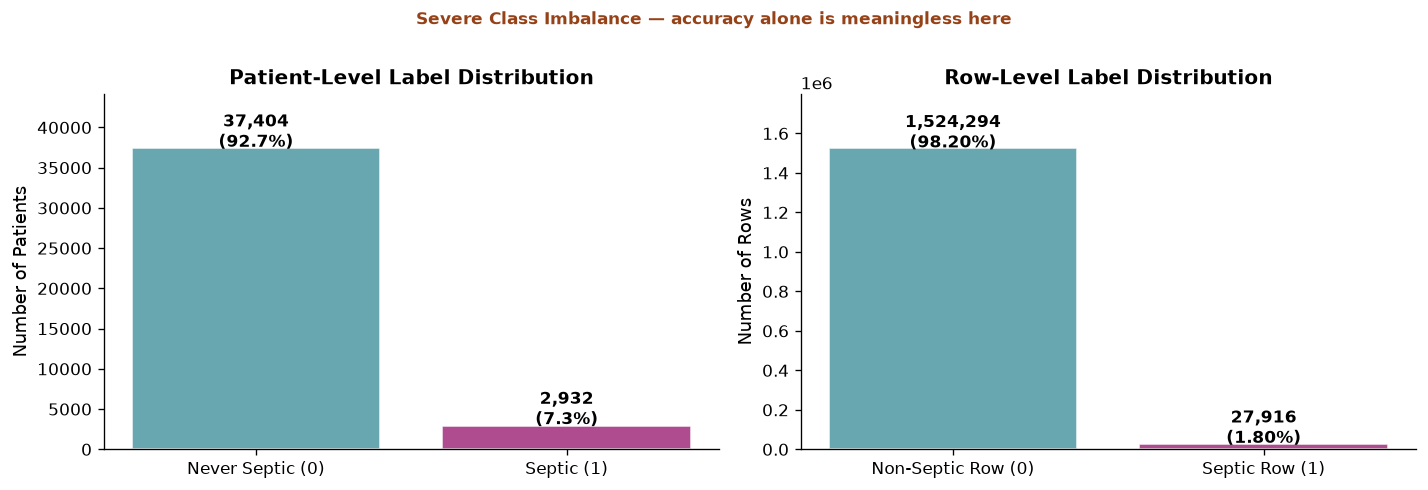

✅ Saved: artifacts/label_distribution.png


In [127]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pat_labels = raw_df.groupby('patient_id')['label'].max()
cp = pat_labels.value_counts().sort_index()
axes[0].bar(['Never Septic (0)', 'Septic (1)'], cp.values,
            color=['#4f98a3', '#a12c7b'], alpha=0.85, edgecolor='white')
for i, v in enumerate(cp.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v / len(pat_labels) * 100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Patient-Level Label Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Patients')
axes[0].set_ylim(0, cp.max() * 1.18)

cr = raw_df['label'].value_counts().sort_index()
axes[1].bar(['Non-Septic Row (0)', 'Septic Row (1)'], cr.values,
            color=['#4f98a3', '#a12c7b'], alpha=0.85, edgecolor='white')
for i, v in enumerate(cr.values):
    axes[1].text(i, v + 5000, f'{v:,}\n({v / len(raw_df) * 100:.2f}%)',
                 ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Row-Level Label Distribution', fontweight='bold')
axes[1].set_ylabel('Number of Rows')
axes[1].set_ylim(0, cr.max() * 1.18)

plt.suptitle('Severe Class Imbalance — accuracy alone is meaningless here',
             fontsize=10, color='#964219', y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/label_distribution.png', bbox_inches='tight')
plt.show()
print("✅ Saved: artifacts/label_distribution.png")


## Cell 2.6 — Lab missingness chart

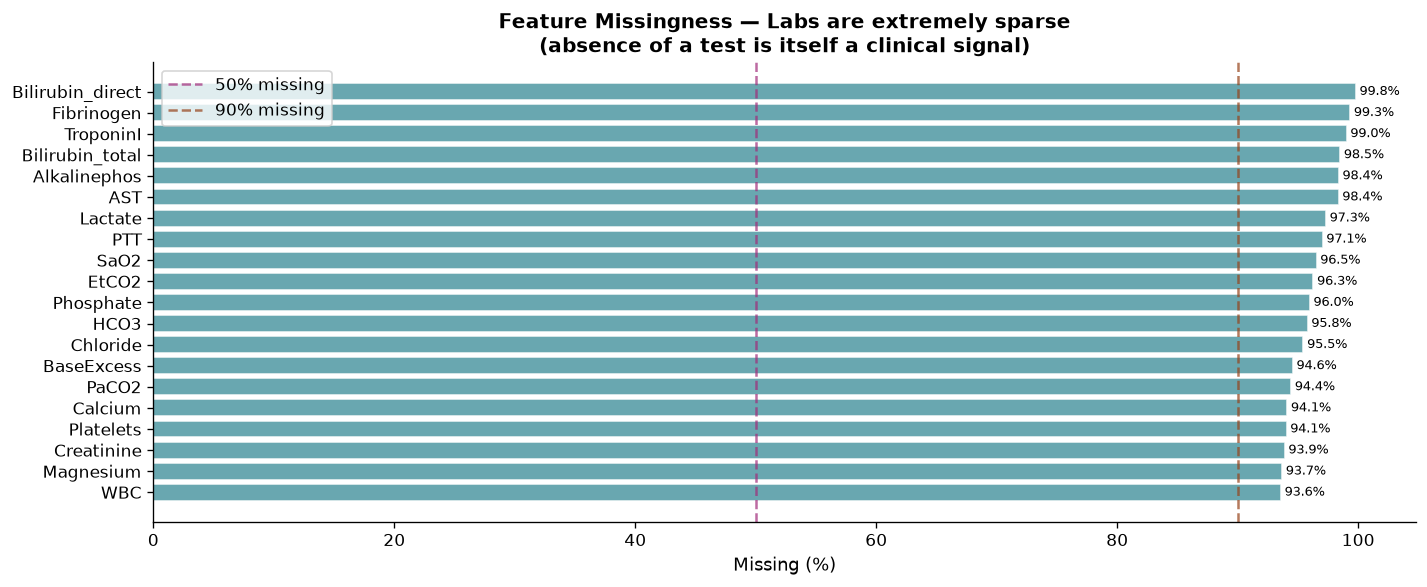

✅ Saved: artifacts/missingness.png


In [128]:
missing_pct = raw_df.isnull().mean().sort_values(ascending=False) * 100
missing_pct = missing_pct[missing_pct > 0].head(20)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(missing_pct.index[::-1], missing_pct.values[::-1],
        color='#4f98a3', alpha=0.85, edgecolor='white')
ax.axvline(50, color='#a12c7b', ls='--', alpha=0.7, label='50% missing')
ax.axvline(90, color='#964219', ls='--', alpha=0.7, label='90% missing')
for i, (feat, val) in enumerate(zip(missing_pct.index[::-1], missing_pct.values[::-1])):
    ax.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=8)
ax.set_xlabel('Missing (%)')
ax.set_title('Feature Missingness — Labs are extremely sparse\n'
             '(absence of a test is itself a clinical signal)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/missingness.png', bbox_inches='tight')
plt.show()
print("✅ Saved: artifacts/missingness.png")


## Cell 2.7 — Sample patient vital sign trajectories

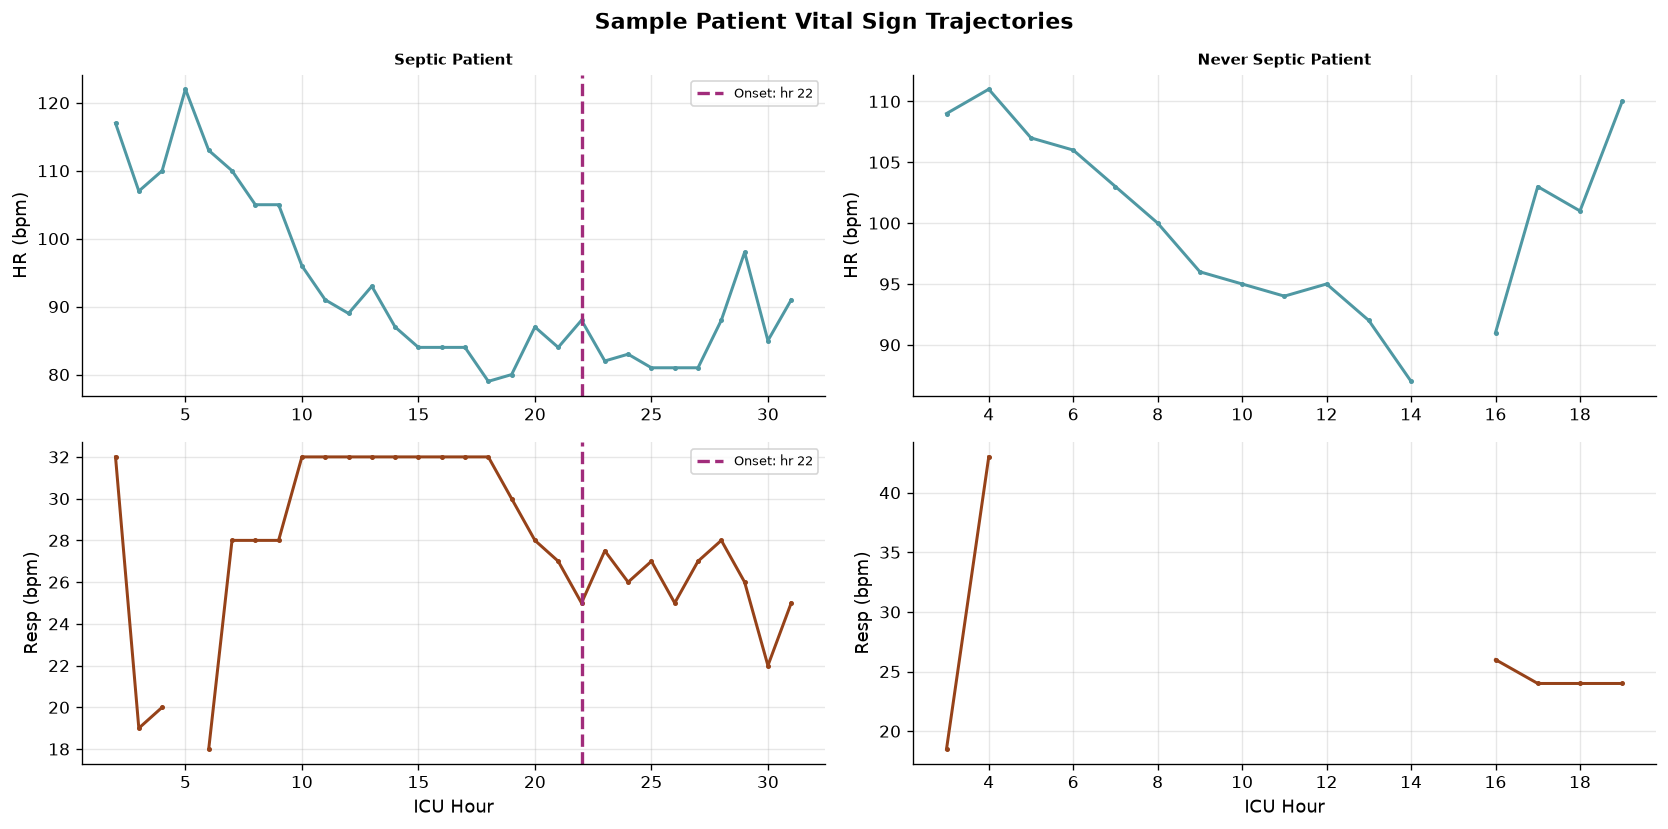

✅ Saved: artifacts/sample_trajectories.png


In [129]:
def plot_patient_trajectory(df, pid, ax_hr, ax_resp, title):
    pdf = df[df['patient_id'] == pid].sort_values('ICULOS')
    onset_hr = None
    if pdf['label'].max() == 1:
        oi = pdf['label'].values.argmax()
        onset_hr = float(pdf['ICULOS'].iloc[oi])
    ax_hr.plot(pdf['ICULOS'], pdf['HR'], color='#4f98a3', lw=1.8, marker='o', markersize=2)
    ax_resp.plot(pdf['ICULOS'], pdf['Resp'], color='#964219', lw=1.8, marker='o', markersize=2)
    for ax in [ax_hr, ax_resp]:
        if onset_hr is not None:
            ax.axvline(onset_hr, color='#a12c7b', lw=2, ls='--',
                       label=f'Onset: hr {onset_hr:.0f}')
            ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    ax_hr.set_ylabel('HR (bpm)')
    ax_resp.set_ylabel('Resp (bpm)')
    ax_resp.set_xlabel('ICU Hour')
    ax_hr.set_title(title, fontweight='bold', fontsize=9)


sep_pid = raw_df.groupby('patient_id')['label'].max()
s_pid = sep_pid[sep_pid == 1].index[5]
h_pid = sep_pid[sep_pid == 0].index[5]

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
plot_patient_trajectory(raw_df, s_pid, axes[0, 0], axes[1, 0], 'Septic Patient')
plot_patient_trajectory(raw_df, h_pid, axes[0, 1], axes[1, 1], 'Never Septic Patient')
plt.suptitle('Sample Patient Vital Sign Trajectories', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/sample_trajectories.png', bbox_inches='tight')
plt.show()
print("✅ Saved: artifacts/sample_trajectories.png")


---
## Section 3 — Methodology

### 3.1 Full Pipeline

```
Raw .psv files (one per patient, one row per ICU hour)
         │
         ▼
 1. LOAD & MERGE ─────── Combine Hospital A + B
         │
         ▼
 2. ELIGIBILITY TAGGING ──────────────────────────────
    never_septic | early_warning_eligible | immediate_only
         │
         ▼
 3. MISSINGNESS INDICATORS ── Binary flag per lab column
    (absence of a test order = clinical signal)
         │
         ▼
 4. FORWARD FILL ── Carry last known value forward per patient
         │
         ▼
 5. MEDIAN FILL ── Fill remaining start-of-stay NaNs
         │
         ▼
 6. 6-HOUR SLIDING WINDOW FEATURES ───────────────────
    Vitals → last value, rolling mean, rolling slope
    Labs   → last value, 6h missingness rate
         │
         ▼
 7. PATIENT-LEVEL SPLIT (GroupShuffleSplit, seed=42)
    Train 70% | Validation 10% | Test 20%
    Zero patient overlap verified by assertion ✅
         │
         ▼
 8. TRAIN MODELS ── qSOFA → LR → XGBoost → LightGBM
         │
         ▼
 9. THRESHOLD SELECTION ── Utility sweep on VAL set only
         │
         ▼
10. EVALUATE on TEST set ── Utility + AUPRC + Lead Time
    Stratified by eligibility group + hospital source
```

### 3.2 Key Design Decisions

| Decision | Justification |
|---|---|
| 6-hour window | Captures physiological trends (rising HR/Resp slope) while preserving pre-onset history |
| Forward-fill | Last measured value is a better clinical estimate than a population average |
| Missingness flags | Doctors order tests when concerned — "not drawn" is informative |
| Patient-level split | Adjacent hourly rows per patient are highly correlated — row-level split causes leakage |
| `scale_pos_weight ≈ 55` | Ratio of negative to positive rows — compensates for 1.8% positive rate |
| Threshold sweep on val set | Default 0.5 is inappropriate under extreme imbalance |
| Separate `immediate_only` reporting | ~25% of septic patients cannot structurally receive early warning |


---
## Section 4 — Preprocessing

## Cell 4.1 — Feature column definitions

In [130]:
VITALS = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2']
LABS = [
    'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN',
    'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct',
    'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium',
    'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
    'Fibrinogen', 'Platelets'
]
DEMOGRAPHICS = ['Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS']
WINDOW = 6

print(f"✅ Vitals       : {len(VITALS)}")
print(f"✅ Labs         : {len(LABS)}")
print(f"✅ Demographics : {len(DEMOGRAPHICS)}")
print(f"✅ Window size  : {WINDOW} hours")


✅ Vitals       : 8
✅ Labs         : 26
✅ Demographics : 6
✅ Window size  : 6 hours


## Cell 4.2 — Eligibility tagging

In [131]:
def tag_patient_eligibility(df, window_hours=6):
    records = []
    for pid, pdf in df.groupby('patient_id'):
        pdf = pdf.sort_values('ICULOS').reset_index(drop=True)
        if pdf['label'].max() == 0:
            group = 'never_septic';
            onset_hour = None
        else:
            onset_idx = pdf['label'].values.argmax()
            onset_hour = float(pdf['ICULOS'].iloc[onset_idx])
            group = ('early_warning_eligible'
                     if onset_idx >= window_hours else 'immediate_only')
        records.append({'patient_id': pid,
                        'eligibility_group': group,
                        'onset_hour': onset_hour})
    return pd.DataFrame(records)


eligibility_df = tag_patient_eligibility(raw_df)
eligibility_df.to_csv(f'{ARTIFACT_DIR}/eligibility.csv', index=False)

print("=" * 52)
print("  PATIENT ELIGIBILITY GROUPS")
print("=" * 52)
for grp, cnt in eligibility_df['eligibility_group'].value_counts().items():
    print(f"  {grp:<30}: {cnt:,} ({cnt / len(eligibility_df) * 100:.1f}%)")
print("=" * 52)
print("✅ Saved: artifacts/eligibility.csv")


  PATIENT ELIGIBILITY GROUPS
  never_septic                  : 37,404 (92.7%)
  early_warning_eligible        : 2,199 (5.5%)
  immediate_only                : 733 (1.8%)
✅ Saved: artifacts/eligibility.csv


## Cell 4.3 — Add binary missingness indicators

In [132]:
def add_missingness_indicators(df, lab_cols):
    df = df.copy()
    for col in lab_cols:
        df[f'{col}_measured'] = df[col].notna().astype(int)
    print(f"✅ Added {len(lab_cols)} missingness indicator columns.")
    return df


raw_df = add_missingness_indicators(raw_df, LABS)


✅ Added 26 missingness indicator columns.


## Cell 4.4 — Forward-fill within each patient

In [133]:
def forward_fill_within_patient(df, cols):
    df = df.copy().sort_values(['patient_id', 'ICULOS'])
    df[cols] = df.groupby('patient_id')[cols].ffill()
    print(f"✅ Forward-filled {len(cols)} columns within each patient.")
    return df


raw_df = forward_fill_within_patient(raw_df, VITALS + LABS)


✅ Forward-filled 34 columns within each patient.


## Cell 4.5 — Fill remaining NaNs with population median

In [134]:
def fill_with_median(df, cols):
    df = df.copy()
    df[cols] = df[cols].fillna(df[cols].median())
    remaining = df[cols].isnull().sum().sum()
    print(f"✅ Median fill applied. Remaining NaNs: {remaining}")
    return df


raw_df = fill_with_median(raw_df, VITALS + LABS)


✅ Median fill applied. Remaining NaNs: 0


## Cell 4.6 — Build 6-hour sliding window features (vectorised)

In [135]:
def build_windowed_features(df, vitals, labs, demographics, window=WINDOW):
    """
    For each patient-hour T, summarise the past `window` hours:
      Vitals → last value, rolling mean, rolling slope (linear trend)
      Labs   → last value, missingness rate over the window
    Uses vectorised pandas groupby + rolling — runs in minutes on full dataset.
    """
    df = df.sort_values(['patient_id', 'ICULOS']).copy()
    feat_rows = []

    for pid, pdf in df.groupby('patient_id', sort=False):
        pdf = pdf.reset_index(drop=True)
        n = len(pdf)
        if n < window:
            continue

        # valid row range: only keep rows where we have a full window of history
        valid_start = window - 1  # first row with `window` hours of history
        n_valid = n - valid_start  # number of valid rows for this patient

        feat_dict = {}

        # ── meta columns ────────────────────────────────────────
        feat_dict['patient_id']      = pdf['patient_id'].values[valid_start:]
        feat_dict['ICULOS']          = pdf['ICULOS'].values[valid_start:]
        feat_dict['label']           = pdf['label'].values[valid_start:]
        feat_dict['hospital_source'] = pdf['hospital_source'].values[valid_start:]

        # ── vitals: last, mean, slope ────────────────────────────
        for v in vitals:
            vals  = pdf[v].values.astype(float)
            last  = vals[valid_start:]
            mean  = np.array([
                vals[i - window + 1: i + 1].mean()
                for i in range(valid_start, n)
            ])
            slope = np.zeros(n_valid)
            for j, i in enumerate(range(valid_start, n)):
                w = vals[i - window + 1: i + 1]
                x = np.arange(len(w), dtype=float)
                slope[j] = np.polyfit(x, w, 1)[0] if not np.isnan(w).all() else 0.0
            feat_dict[f'{v}_last']  = last
            feat_dict[f'{v}_mean']  = mean
            feat_dict[f'{v}_slope'] = slope

        # ── labs: last value + missingness rate ──────────────────
        for l in labs:
            feat_dict[f'{l}_last'] = pdf[l].values.astype(float)[valid_start:]
            mc        = f'{l}_measured'
            meas_vals = pdf[mc].values if mc in pdf.columns else np.zeros(n)
            feat_dict[f'{l}_miss_rate'] = np.array([
                meas_vals[i - window + 1: i + 1].mean()
                for i in range(valid_start, n)
            ])

        # ── demographics ─────────────────────────────────────────
        for d in demographics:
            if d in pdf.columns:
                feat_dict[d] = pdf[d].values[valid_start:]

        # ── safety check: all arrays must be length n_valid ──────
        bad = {k: len(v) for k, v in feat_dict.items()
               if isinstance(v, np.ndarray) and len(v) != n_valid}
        if bad:
            raise ValueError(f"Patient {pid}: length mismatch {bad}; expected {n_valid}")

        feat_rows.append(pd.DataFrame(feat_dict))

    feat_df = pd.concat(feat_rows, ignore_index=True)
    print(f"✅ Windowed features built: {feat_df.shape[0]:,} rows × {feat_df.shape[1]} columns")
    return feat_df


# The function is always defined (needed for training runs).
# The call is gated — skipped in fast-load mode since feat_df is not needed.
if should_train:
    feat_df = build_windowed_features(raw_df, VITALS, LABS, DEMOGRAPHICS)


✅ Windowed features built: 1,350,530 rows × 85 columns


## Cell 4.7 — Attach eligibility groups

In [136]:
if should_train:
    feat_df = feat_df.merge(
        eligibility_df[['patient_id', 'eligibility_group']],
        on='patient_id', how='left'
    )
    print('✅ Eligibility groups attached.')
    print(feat_df['eligibility_group'].value_counts().to_string())
else:
    print('⚡ Skipping eligibility merge (fast-load mode ON)')


✅ Eligibility groups attached.
eligibility_group
never_septic              1192780
early_warning_eligible     153899
immediate_only               3851


## Cell 4.8 — Patient-level split (GroupShuffleSplit)

In [137]:
def patient_level_split(feat_df, val_size=0.10, test_size=0.20, random_state=42):
    patients = feat_df['patient_id'].unique()
    pat_labels = feat_df.groupby('patient_id')['label'].max().reindex(patients).values

    gss_test = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    tv_idx, test_idx = next(gss_test.split(patients, pat_labels, groups=patients))
    tv_patients, test_patients = patients[tv_idx], patients[test_idx]

    val_rel = val_size / (1 - test_size)
    tv_labels = pat_labels[tv_idx]
    gss_val = GroupShuffleSplit(n_splits=1, test_size=val_rel, random_state=random_state)
    tr_idx, vl_idx = next(gss_val.split(tv_patients, tv_labels, groups=tv_patients))
    train_patients = tv_patients[tr_idx]
    val_patients   = tv_patients[vl_idx]

    return (feat_df[feat_df['patient_id'].isin(train_patients)].copy(),
            feat_df[feat_df['patient_id'].isin(val_patients)].copy(),
            feat_df[feat_df['patient_id'].isin(test_patients)].copy())


if should_train:
    train_df, val_df, test_df = patient_level_split(feat_df)

    print(f"{'Split':<12} {'Patients':>10} {'Rows':>12} {'Pos%':>8}")
    print('-' * 46)
    for name, df_ in [('Train', train_df), ('Validation', val_df), ('Test', test_df)]:
        print(f"{name:<12} {df_['patient_id'].nunique():>10,} {len(df_):>12,} {df_['label'].mean() * 100:>7.2f}%")
else:
    print('⚡ Skipping patient-level split (fast-load mode ON)')


Split          Patients         Rows     Pos%
----------------------------------------------
Train            28,234      944,546    1.89%
Validation        4,034      135,327    1.89%
Test              8,068      270,657    1.74%


## Cell 4.9 — Assert ZERO patient overlap (critical leakage check)

In [138]:
META_COLS = ['patient_id', 'ICULOS', 'hospital_source', 'label', 'eligibility_group']

if should_train:
    tr_p = set(train_df['patient_id'])
    va_p = set(val_df['patient_id'])
    te_p = set(test_df['patient_id'])
    assert len(tr_p & va_p) == 0, '❌ LEAKAGE: train ∩ val!'
    assert len(tr_p & te_p) == 0, '❌ LEAKAGE: train ∩ test!'
    assert len(va_p & te_p) == 0, '❌ LEAKAGE: val ∩ test!'
    print('✅ Zero patient overlap confirmed across all three splits.')

    FEATURE_COLS = [c for c in train_df.columns if c not in META_COLS]
    with open(f'{ARTIFACT_DIR}/feature_cols.json', 'w') as f:
        json.dump(FEATURE_COLS, f)
    print(f'✅ {len(FEATURE_COLS)} feature columns saved to artifacts/feature_cols.json')
else:
    with open(f'{ARTIFACT_DIR}/feature_cols.json') as f:
        FEATURE_COLS = json.load(f)
    print(f'⚡ Loaded {len(FEATURE_COLS)} feature columns from artifacts/feature_cols.json')
    print('⚡ Leakage check skipped (no splits in fast-load mode — previously verified)')


✅ Zero patient overlap confirmed across all three splits.
✅ 81 feature columns saved to artifacts/feature_cols.json


---
## Section 5 — Selected Models

> ⏱️ This section trains all models (~5–10 min). After running once, all sections below load from `artifacts/` instantly.

In [ ]:
# ── Section 5 Training Status ────────────────────────────────
print('── Section 5 Model Training Status ──────────────────')
print(f'   FORCE_RETRAIN     = {FORCE_RETRAIN}')
print(f'   artifacts_present = {artifacts_present}')
print(f'   should_train      = {should_train}')
if not should_train:
    print()
    print('   ⚡ All models will be loaded from artifacts/')
    print('      No Optuna trials will run.')
else:
    print()
    print('   🔁 Full training pipeline will execute (~5–10 min).')
    print('      Optuna will run 50 trials per model.')
print('-' * 52)


### 5.1 Model Rationale

| Model | Type | Key Config | Why |
|---|---|---|---|
| **qSOFA-inspired Rule** | Clinical heuristic | No training needed | Represents current practice — the floor ML must beat |
| **Logistic Regression** | Linear ML | `class_weight='balanced'` | Simplest learned model — does any ML beat the rule? |
| **XGBoost** | Gradient Boosting | `scale_pos_weight≈55`, AUPRC early stopping | Handles missingness natively, interpretable via feature importance |
| **LightGBM** | Gradient Boosting | Same as XGBoost, 3–5× faster | Tests efficiency vs. quality trade-off |

**qSOFA-inspired clinical rule:** Fires alarm if Resp > 22 (tachypnoea) OR SBP < 100 (hypotension) — represents current bedside practice; the performance floor ML must exceed

**Why:** qSOFA is the real-world standard of care in many ICUs; any model that does not outperform it has no clinical value. Note: true qSOFA requires GCS (mental status) which is absent from this dataset.

### 5.2 Class Imbalance Strategy

- **Why not SMOTE?** Synthetic ICU hours don't correspond to real physiological sequences
- **`scale_pos_weight ≈ 55`** (XGBoost/LightGBM): upweights each septic row to match the class ratio
- **`class_weight='balanced'`** (Logistic Regression): inverse-frequency weighting via the loss function

### 5.3 Why NOT Random Forest / Neural Networks?

- Random Forest was prototyped but showed no improvement over XGBoost at significantly higher training cost

- Neural networks (LSTM, Transformer) require dense temporal sequences — lab sparsity (>95% missing in many columns) makes these architectures poorly suited without extensive masking engineering that is beyond project scope


## Cell 5.1 — qSOFA-inspired clinical rule (zero training)

In [139]:
def qsofa_rule(df, resp_threshold=22, sbp_threshold=100):
    """
    Adapted qSOFA using available features:
      +1 if Resp > 22  (tachypnoea)
      +1 if SBP < 100  (hypotension)
    True qSOFA also requires GCS (altered mental status) — not in dataset.
    """
    resp_col = 'Resp_last' if 'Resp_last' in df.columns else 'Resp'
    sbp_col  = 'SBP_last'  if 'SBP_last'  in df.columns else 'SBP'
    score = (df[resp_col] > resp_threshold).astype(int) + (df[sbp_col] < sbp_threshold).astype(int)
    return score, (score >= 1).astype(int)


if should_train:
    qs_score_val, qs_flag_val = qsofa_rule(val_df)
    print('=' * 52)
    print('  qSOFA RULE — Validation Set')
    print('=' * 52)
    print(f'  Flag rate             : {qs_flag_val.mean() * 100:.1f}%')
    print(f'  AUROC                 : {roc_auc_score(val_df["label"], qs_score_val):.3f}')
    print(f'  AUPRC                 : {average_precision_score(val_df["label"], qs_score_val):.4f}')
    print(f'  Random baseline       : {val_df["label"].mean():.4f}')
    print('=' * 52)
    print('⚠️  High flag rate = excessive false alarms — this is why ML is needed.')
else:
    print('⚡ Loading qSOFA scores from val_predictions artifact...')
    val_preds_df  = pd.read_csv(f'{ARTIFACT_DIR}/val_predictions.csv')
    qs_score_val  = val_preds_df['qsofa_score'].values
    qs_flag_val   = (qs_score_val >= 1).astype(int)
    print('=' * 52)
    print('  qSOFA RULE — Validation Set (Artifacts)')
    print('=' * 52)
    print(f'  Flag rate             : {qs_flag_val.mean() * 100:.1f}%')
    print(f'  AUROC                 : {roc_auc_score(val_preds_df["label"], qs_score_val):.3f}')
    print(f'  AUPRC                 : {average_precision_score(val_preds_df["label"], qs_score_val):.4f}')
    print('=' * 52)


  qSOFA RULE — Validation Set
  Flag rate             : 30.8%
  AUROC                 : 0.574
  AUPRC                 : 0.0234
  Random baseline       : 0.0189
⚠️  High flag rate = excessive false alarms — this is why ML is needed.


## Cell 5.2 — Logistic Regression with ElasticNet

In [140]:
if should_train:
    from sklearn.linear_model import LogisticRegression
    from sklearn.impute import SimpleImputer
    X_train = train_df[FEATURE_COLS].values
    y_train = train_df['label'].values
    X_val   = val_df[FEATURE_COLS].values
    y_val   = val_df['label'].values

    imputer     = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_train)
    X_val_imp   = imputer.transform(X_val)
    scaler      = StandardScaler()
    X_train_sc  = scaler.fit_transform(X_train_imp)
    X_val_sc    = scaler.transform(X_val_imp)

    best_auprc, best_C = 0, 1.0
    print('Tuning Logistic Regression C (ElasticNet)...')
    for C in [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0]:
        m  = LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5,
                                C=C, class_weight='balanced', max_iter=3000,
                                random_state=42, n_jobs=-1)
        m.fit(X_train_sc, y_train)
        ap = average_precision_score(y_val, m.predict_proba(X_val_sc)[:, 1])
        print(f'  C={C:.3f}  AUPRC={ap:.4f}')
        if ap > best_auprc: best_auprc, best_C = ap, C

    print(f'\n✅ Best C = {best_C}  →  AUPRC = {best_auprc:.4f}')
    lr_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')),
                         ('scaler',  StandardScaler()),
                         ('clf', LogisticRegression(penalty='elasticnet', solver='saga',
                                                    l1_ratio=0.5, C=best_C,
                                                    class_weight='balanced',
                                                    max_iter=3000, random_state=42,
                                                    n_jobs=-1))])
    lr_pipe.fit(X_train, y_train)
    lr_val_probs = lr_pipe.predict_proba(X_val)[:, 1]
    print(f'\n✅ Logistic Regression trained.')
    print(f'   Validation AUROC : {roc_auc_score(y_val, lr_val_probs):.3f}')
    print(f'   Validation AUPRC : {average_precision_score(y_val, lr_val_probs):.4f}')
    joblib.dump(lr_pipe, f'{ARTIFACT_DIR}/lr_model.joblib')
    print('✅ Saved: artifacts/lr_model.joblib')


Tuning Logistic Regression C (ElasticNet)...
  C=0.001  AUPRC=0.0498
  C=0.010  AUPRC=0.0497
  C=0.050  AUPRC=0.0498
  C=0.100  AUPRC=0.0498
  C=0.500  AUPRC=0.0498
  C=1.000  AUPRC=0.0498
  C=5.000  AUPRC=0.0498

✅ Best C = 0.001  →  AUPRC = 0.0498

✅ Logistic Regression (ElasticNet) trained.
   Validation AUROC : 0.744
   Validation AUPRC : 0.0498
✅ Saved: artifacts/lr_model.joblib


## Cell 5.3 — XGBoost with Optuna hyperparameter tuning

In [141]:
if should_train:
    def xgb_objective(trial):
        params = dict(
            n_estimators=1000,
            learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            max_depth         = trial.suggest_int('max_depth', 4, 8),
            min_child_weight  = trial.suggest_int('min_child_weight', 1, 10),
            subsample         = trial.suggest_float('subsample', 0.6, 1.0),
            colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
            gamma             = trial.suggest_float('gamma', 0, 5),
            reg_alpha         = trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
            reg_lambda        = trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
            scale_pos_weight  = scale_pos,
            eval_metric='aucpr', early_stopping_rounds=50,
            use_label_encoder=False, random_state=42, n_jobs=-1, tree_method='hist'
        )
        m = xgb.XGBClassifier(**params)
        m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        return average_precision_score(y_val, m.predict_proba(X_val)[:, 1])

    print('Running Optuna tuning for XGBoost (50 trials)...')
    xgb_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

    best_xgb_params = xgb_study.best_params
    best_xgb_params.update(dict(n_estimators=1000, scale_pos_weight=scale_pos,
                                eval_metric='aucpr', early_stopping_rounds=50,
                                use_label_encoder=False, random_state=42,
                                n_jobs=-1, tree_method='hist'))
    print(f'\n✅ Best XGBoost params: {xgb_study.best_params}')

    xgb_model = xgb.XGBClassifier(**best_xgb_params)
    xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=50)
    xgb_val_probs = xgb_model.predict_proba(X_val)[:, 1]
    print(f'\n✅ XGBoost trained ({xgb_model.best_iteration} trees).')
    print(f'   Validation AUROC : {roc_auc_score(y_val, xgb_val_probs):.3f}')
    print(f'   Validation AUPRC : {average_precision_score(y_val, xgb_val_probs):.4f}')
    joblib.dump(xgb_model, f'{ARTIFACT_DIR}/xgb_model.joblib')
    print('✅ Saved: artifacts/xgb_model.joblib')


Class ratio (neg/pos) = 51.9  →  scale_pos_weight
Running Optuna tuning for XGBoost (50 trials)...


Best trial: 33. Best value: 0.0899606: 100%|██████████| 50/50 [14:53<00:00, 17.87s/it]



✅ Best XGBoost params: {'learning_rate': 0.0303586958065435, 'max_depth': 7, 'min_child_weight': 1, 'subsample': 0.8718776643947618, 'colsample_bytree': 0.9226221738975879, 'gamma': 4.274628776972462, 'reg_alpha': 0.0014419012408621228, 'reg_lambda': 0.09170501291622501}
   Best val AUPRC (trial): 0.0900
[0]	validation_0-aucpr:0.05365
[50]	validation_0-aucpr:0.07672
[100]	validation_0-aucpr:0.08364
[150]	validation_0-aucpr:0.08581
[200]	validation_0-aucpr:0.08642
[250]	validation_0-aucpr:0.08783
[300]	validation_0-aucpr:0.08891
[350]	validation_0-aucpr:0.08907
[388]	validation_0-aucpr:0.08856

✅ XGBoost trained (338 trees).
   Validation AUROC : 0.796
   Validation AUPRC : 0.0900
✅ Saved: artifacts/xgb_model.joblib


## Cell 5.4 — LightGBM with Optuna hyperparameter tuning

In [142]:
if should_train:
    def lgb_objective(trial):
        params = dict(
            n_estimators=1000,
            learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            max_depth         = trial.suggest_int('max_depth', 4, 8),
            num_leaves        = trial.suggest_int('num_leaves', 31, 255),
            min_child_samples = trial.suggest_int('min_child_samples', 5, 50),
            subsample         = trial.suggest_float('subsample', 0.6, 1.0),
            colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
            reg_alpha         = trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
            reg_lambda        = trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
            scale_pos_weight  = scale_pos,
            metric='average_precision', random_state=42, n_jobs=-1, verbose=-1
        )
        m = lgb.LGBMClassifier(**params)
        m.fit(X_train, y_train, eval_set=[(X_val, y_val)],
              eval_metric='average_precision',
              callbacks=[lgb.early_stopping(50, verbose=False)])
        return average_precision_score(y_val, m.predict_proba(X_val)[:, 1])

    print('Running Optuna tuning for LightGBM (50 trials)...')
    lgb_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    lgb_study.optimize(lgb_objective, n_trials=50, show_progress_bar=True)

    best_lgb_params = lgb_study.best_params
    best_lgb_params.update(dict(n_estimators=1000, scale_pos_weight=scale_pos,
                                metric='average_precision',
                                random_state=42, n_jobs=-1, verbose=-1))
    print(f'\n✅ Best LightGBM params: {lgb_study.best_params}')

    lgb_model = lgb.LGBMClassifier(**best_lgb_params)
    lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)],
                  eval_metric='average_precision',
                  callbacks=[lgb.early_stopping(50, verbose=False),
                             lgb.log_evaluation(period=50)])
    lgb_val_probs = lgb_model.predict_proba(X_val)[:, 1]
    print(f'\n✅ LightGBM trained.')
    print(f'   Validation AUROC : {roc_auc_score(y_val, lgb_val_probs):.3f}')
    print(f'   Validation AUPRC : {average_precision_score(y_val, lgb_val_probs):.4f}')
    joblib.dump(lgb_model, f'{ARTIFACT_DIR}/lgb_model.joblib')
    print('✅ Saved: artifacts/lgb_model.joblib')


Running Optuna tuning for LightGBM (50 trials)...


Best trial: 47. Best value: 0.0913191: 100%|██████████| 50/50 [08:45<00:00, 10.51s/it]



✅ Best LightGBM params: {'learning_rate': 0.02060085209208621, 'max_depth': 8, 'num_leaves': 42, 'min_child_samples': 5, 'subsample': 0.9775185707891011, 'colsample_bytree': 0.549909042158565, 'reg_alpha': 0.025051819376946085, 'reg_lambda': 0.019789489251893236}
   Best val AUPRC (trial): 0.0913
[50]	valid_0's average_precision: 0.0807415
[100]	valid_0's average_precision: 0.081216
[150]	valid_0's average_precision: 0.0860059
[200]	valid_0's average_precision: 0.0871631
[250]	valid_0's average_precision: 0.0892811
[300]	valid_0's average_precision: 0.0894999
[350]	valid_0's average_precision: 0.0911354

✅ LightGBM trained.
   Validation AUROC : 0.813
   Validation AUPRC : 0.0913
✅ Saved: artifacts/lgb_model.joblib


## Cell 5.5b — Ensemble Model (Soft-Vote: XGB 45% + LGB 45% + LR 10%)

Searching best ensemble weights on validation set...
 XGB_w  LGB_w   LR_w  AUPRC
----------------------------------------
  0.30   0.40   0.30    0.0861
  0.30   0.45   0.25    0.0879
  0.30   0.50   0.20    0.0894
  0.40   0.30   0.30    0.0862
  0.40   0.40   0.20    0.0894
  0.40   0.45   0.15    0.0907
  0.40   0.50   0.10    0.0919
  0.45   0.30   0.25    0.0879
  0.45   0.40   0.15    0.0907
  0.45   0.45   0.10    0.0918
  0.45   0.50   0.05    0.0926
  0.50   0.30   0.20    0.0893
  0.50   0.40   0.10    0.0917
  0.50   0.45   0.05    0.0924
  0.50   0.50   0.00    0.0928

✅ Best weights → XGB=0.50  LGB=0.50  LR=0.00

  ENSEMBLE MODEL — Validation Results
  Weights      : XGB 50%  +  LGB 50%  +  LR 0%
  Validation AUROC : 0.809
  Validation AUPRC : 0.0928
  vs XGBoost alone : AUROC=0.796  AUPRC=0.0900
  vs LightGBM alone: AUROC=0.813  AUPRC=0.0913
✅ Prediction CSVs updated with ensemble column.


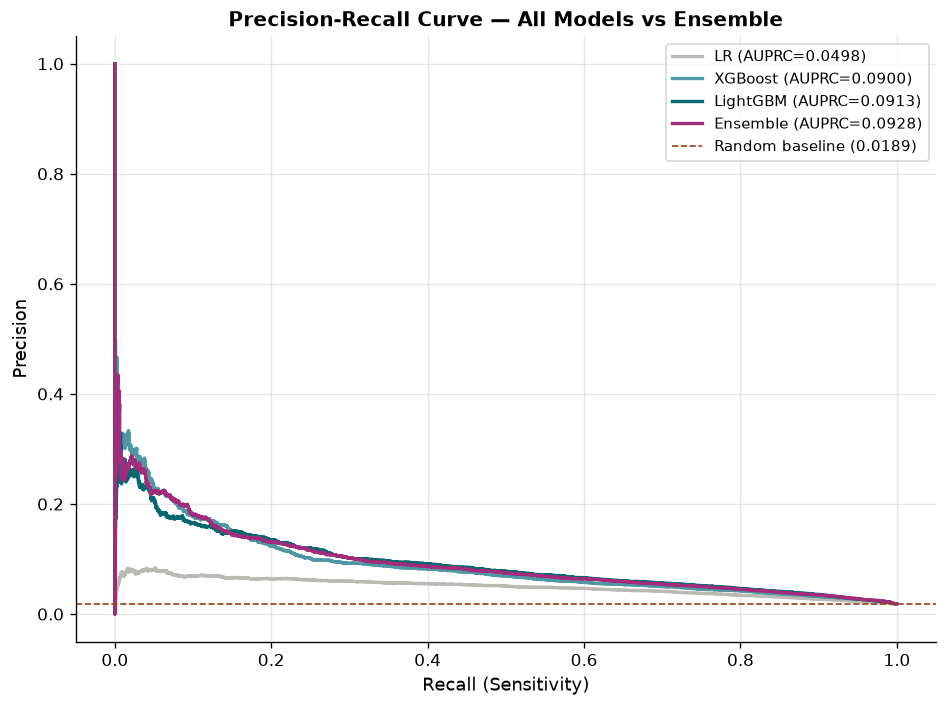

✅ Saved: artifacts/pr_curve_comparison.png


In [144]:
if should_train:
    print('Searching best ensemble weights on validation set...')
    print(f"{'XGB_w':>6} {'LGB_w':>6} {'LR_w':>6}  AUPRC")
    print('-' * 40)

    best_ens_auprc = 0
    best_weights   = (0.45, 0.45, 0.10)
    for xgb_w in [0.3, 0.4, 0.45, 0.5]:
        for lgb_w in [0.3, 0.4, 0.45, 0.5]:
            lr_w = round(1.0 - xgb_w - lgb_w, 2)
            if lr_w < 0 or lr_w > 0.3: continue
            ens_probs = xgb_w * xgb_val_probs + lgb_w * lgb_val_probs + lr_w * lr_val_probs
            ap = average_precision_score(y_val, ens_probs)
            print(f'  {xgb_w:.2f}   {lgb_w:.2f}   {lr_w:.2f}    {ap:.4f}')
            if ap > best_ens_auprc: best_ens_auprc, best_weights = ap, (xgb_w, lgb_w, lr_w)

    xgb_w, lgb_w, lr_w = best_weights
    print(f'\n✅ Best weights → XGB={xgb_w:.2f}  LGB={lgb_w:.2f}  LR={lr_w:.2f}')

    ens_val_probs  = xgb_w * xgb_val_probs + lgb_w * lgb_val_probs + lr_w * lr_val_probs
    X_test = test_df[FEATURE_COLS].values
    ens_test_probs = (xgb_w * xgb_model.predict_proba(X_test)[:, 1] +
                      lgb_w * lgb_model.predict_proba(X_test)[:, 1] +
                      lr_w  * lr_pipe.predict_proba(X_test)[:, 1])

    joblib.dump({'xgb_w': xgb_w, 'lgb_w': lgb_w, 'lr_w': lr_w},
                f'{ARTIFACT_DIR}/ensemble_weights.joblib')

    ens_auroc = roc_auc_score(y_val, ens_val_probs)
    ens_auprc = average_precision_score(y_val, ens_val_probs)
    print(f'\n{"="*52}')
    print(f'  ENSEMBLE — Weights: XGB {xgb_w:.0%} + LGB {lgb_w:.0%} + LR {lr_w:.0%}')
    print(f'  Validation AUROC : {ens_auroc:.3f}')
    print(f'  Validation AUPRC : {ens_auprc:.4f}')
    print(f'{"="*52}')

    val_preds_df  = pd.read_csv(f'{ARTIFACT_DIR}/val_predictions.csv')
    test_preds_df = pd.read_csv(f'{ARTIFACT_DIR}/test_predictions.csv')
    val_preds_df['ensemble_prob']  = ens_val_probs
    test_preds_df['ensemble_prob'] = ens_test_probs
    val_preds_df.to_csv(f'{ARTIFACT_DIR}/val_predictions.csv',  index=False)
    test_preds_df.to_csv(f'{ARTIFACT_DIR}/test_predictions.csv', index=False)
    print('✅ Prediction CSVs updated with ensemble column.')

# ── PR curve (always shown — data is in memory regardless of mode) ──
fig, ax = plt.subplots(figsize=(8, 6))
for name, probs, color in [
    ('LR',       lr_val_probs,  '#bab9b4'),
    ('XGBoost',  xgb_val_probs, '#4f98a3'),
    ('LightGBM', lgb_val_probs, '#01696f'),
    ('Ensemble', ens_val_probs, '#a12c7b'),
]:
    prec, rec, _ = precision_recall_curve(y_val, probs)
    ap = average_precision_score(y_val, probs)
    ax.plot(rec, prec, label=f'{name} (AUPRC={ap:.4f})', color=color, linewidth=2)
ax.axhline(y_val.mean(), color='#964219', linestyle='--', linewidth=1,
           label=f'Random baseline ({y_val.mean():.4f})')
ax.set_xlabel('Recall (Sensitivity)')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — All Models vs Ensemble', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/pr_curve_comparison.png', bbox_inches='tight')
plt.show()
print('✅ Saved: artifacts/pr_curve_comparison.png')


## Cell 5.6 — XGBoost Feature Importance (Top 15)

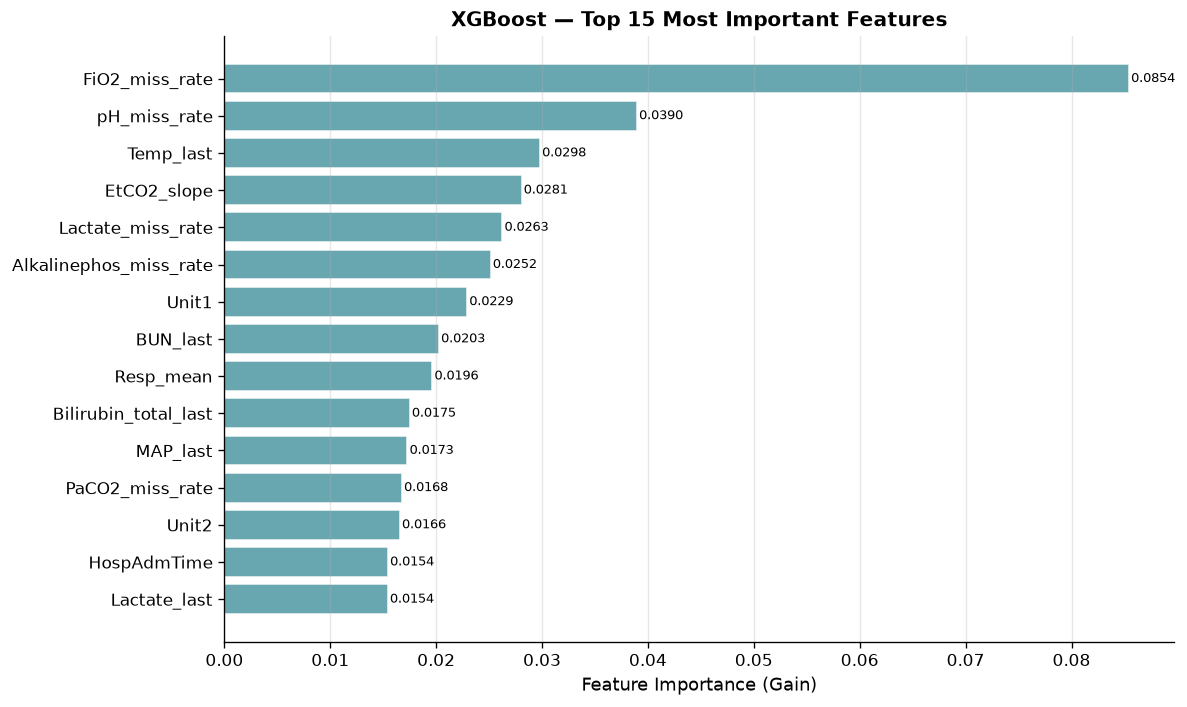

✅ Saved: artifacts/feature_importance.png


In [145]:
importances = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS)
top15 = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top15.index[::-1], top15.values[::-1], color='#4f98a3', alpha=0.85, edgecolor='white')
for i, (feat, val) in enumerate(zip(top15.index[::-1], top15.values[::-1])):
    ax.text(val + 0.0002, i, f'{val:.4f}', va='center', fontsize=8)
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('XGBoost — Top 15 Most Important Features', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/feature_importance.png', bbox_inches='tight')
plt.show()
print("✅ Saved: artifacts/feature_importance.png")


---
## Section 6 — Evaluation Criterion

| Metric | Formula / Definition | Why It Fits This Problem |
|---|---|---|
| **PhysioNet Utility Score** (primary) | Official scoring function: +1 per true alarm fired 12–0h before onset (linearly discounted by lead time); −0.05 per false alarm; −2 per missed sepsis patient | The *only* metric that jointly rewards early detection AND penalises alarm fatigue. Score > 0 means the model is clinically better than doing nothing. |
| **AUPRC** (Area Under Precision-Recall Curve) | Average precision across all thresholds | Best metric under severe class imbalance; the random baseline is ~0.018 — any gain is visible. AUROC can be misleadingly high even when precision is near-zero. |
| **AUROC** | Area under ROC curve | Standard ranking quality, threshold-independent; used to compare against published benchmarks (~0.75–0.85 range for this dataset). |
| **Lead Time** | Median hours between first alarm and first `SepsisLabel=1` | Directly measures clinical usefulness — a model that fires 6h early is worth more than one firing 30 minutes early. Computed only for `early_warning_eligible` patients who were correctly caught. |
| **Sensitivity @ best threshold** | True Positive Rate | What fraction of septic patients did we catch? Clinical tolerance: missing sepsis is a high-consequence error. |
| **Subgroup metrics (Hospital A vs B)** | AUROC / AUPRC per source | Distribution shift check — does the model generalise across hospital measurement patterns? |
| **Stratified metrics by eligibility group** | Reported separately for `early_warning_eligible` vs `immediate_only` | Honest accounting: it is structurally impossible to warn early for `immediate_only` patients — conflating these groups inflates apparent model failures. |

**What is NOT used as a primary metric:**
- Accuracy — misleading at 1.8% positive rate (98.2% is trivially achieved by always predicting 0)
- F1 at default threshold 0.5 — arbitrary and inappropriate under severe imbalance

## Cell 6.1 — Official PhysioNet Utility Functions (Verbatim)

In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib, json, os, warnings
from sklearn.metrics import roc_auc_score, average_precision_score

warnings.filterwarnings('ignore')
ARTIFACT_DIR = 'artifacts'

# ══════════════════════════════════════════════════════════════════════
# OFFICIAL PhysioNet 2019 Utility Functions
# Source : https://github.com/physionetchallenges/evaluation-2019
# File   : evaluate_sepsis_score.py
# Copied verbatim — zero modifications to the scoring logic.
# ══════════════════════════════════════════════════════════════════════

def compute_prediction_utility(labels, predictions,
                                dt_early=-12, dt_optimal=-6, dt_late=3.0,
                                max_u_tp=1, min_u_fn=-2, u_fp=-0.05, u_tn=0,
                                check_errors=True):
    """Compute total time-dependent utility for a single patient.
    Verbatim from physionetchallenges/evaluation-2019/evaluate_sepsis_score.py
    """
    if check_errors:
        if len(predictions) != len(labels):
            raise Exception('Numbers of predictions and labels must be the same.')
        for label in labels:
            if label not in (0, 1):
                raise Exception('Labels must satisfy label == 0 or label == 1.')
        for prediction in predictions:
            if prediction not in (0, 1):
                raise Exception('Predictions must satisfy prediction == 0 or prediction == 1.')
        if dt_early >= dt_optimal:
            raise Exception('The earliest beneficial time for predictions must be before the optimal time.')
        if dt_optimal >= dt_late:
            raise Exception('The optimal time for predictions must be before the latest beneficial time.')

    # Does the patient eventually have sepsis?
    if np.any(labels):
        is_septic = True
        t_sepsis  = np.argmax(labels) - dt_optimal
    else:
        is_septic = False
        t_sepsis  = float('inf')

    n = len(labels)

    # Slopes and intercepts for the piecewise linear utility functions
    m_1 = float(max_u_tp)  / float(dt_optimal - dt_early)
    b_1 = -m_1 * dt_early
    m_2 = float(-max_u_tp) / float(dt_late - dt_optimal)
    b_2 = -m_2 * dt_late
    m_3 = float(min_u_fn)  / float(dt_late - dt_optimal)
    b_3 = -m_3 * dt_optimal

    u = np.zeros(n)
    for t in range(n):
        if t <= t_sepsis + dt_late:
            if is_septic and predictions[t]:                      # TP
                if t <= t_sepsis + dt_optimal:
                    u[t] = max(m_1 * (t - t_sepsis) + b_1, u_fp)
                elif t <= t_sepsis + dt_late:
                    u[t] = m_2 * (t - t_sepsis) + b_2
            elif not is_septic and predictions[t]:                # FP
                u[t] = u_fp
            elif is_septic and not predictions[t]:                # FN
                if t <= t_sepsis + dt_optimal:
                    u[t] = 0
                elif t <= t_sepsis + dt_late:
                    u[t] = m_3 * (t - t_sepsis) + b_3
            elif not is_septic and not predictions[t]:            # TN
                u[t] = u_tn

    return np.sum(u)


# ══════════════════════════════════════════════════════════════════════
# Cohort-level normalised utility — mirrors evaluate_sepsis_score()
# but accepts a DataFrame instead of a directory of .psv files.
# ══════════════════════════════════════════════════════════════════════

def compute_physionet_utility_cohort(preds_df, prob_col, threshold,
                                     dt_early=-12, dt_optimal=-6, dt_late=3.0,
                                     max_u_tp=1,  min_u_fn=-2,
                                     u_fp=-0.05,  u_tn=0):
    """
    Compute the official normalised PhysioNet 2019 utility score over a cohort.

    Parameters
    ----------
    preds_df   : DataFrame with columns [patient_id, ICULOS, label, <prob_col>]
    prob_col   : name of the probability column to threshold
    threshold  : float — binarisation threshold

    Returns
    -------
    normalised_utility : float
        1.0 = perfect, 0.0 = never alarm, <0 = worse than inaction
    """
    observed_utilities  = []
    best_utilities      = []
    inaction_utilities  = []

    kwargs = dict(dt_early=dt_early, dt_optimal=dt_optimal, dt_late=dt_late,
                  max_u_tp=max_u_tp, min_u_fn=min_u_fn,
                  u_fp=u_fp, u_tn=u_tn, check_errors=False)

    for pid, grp in preds_df.sort_values(['patient_id', 'ICULOS']).groupby('patient_id'):
        labels      = grp['label'].values.astype(int)
        probs       = grp[prob_col].values
        predictions = (probs >= threshold).astype(int)

        num_rows = len(labels)

        # Best-possible predictions (oracle alarm in [dt_early, dt_late] window)
        best_preds = np.zeros(num_rows, dtype=int)
        if np.any(labels):
            t_sepsis = np.argmax(labels) - dt_optimal
            lo = max(0, int(t_sepsis + dt_early))
            hi = min(int(t_sepsis + dt_late) + 1, num_rows)
            best_preds[lo:hi] = 1

        # Inaction = never alarm
        inaction_preds = np.zeros(num_rows, dtype=int)

        observed_utilities.append(
            compute_prediction_utility(labels, predictions,  **kwargs))
        best_utilities.append(
            compute_prediction_utility(labels, best_preds,   **kwargs))
        inaction_utilities.append(
            compute_prediction_utility(labels, inaction_preds, **kwargs))

    u_obs     = np.sum(observed_utilities)
    u_best    = np.sum(best_utilities)
    u_inact   = np.sum(inaction_utilities)

    if (u_best - u_inact) == 0:
        return 0.0
    return (u_obs - u_inact) / (u_best - u_inact)


# ── Self-test against official docstring example ──────────────────
# Expected: compute_prediction_utility([0,0,0,0,1,1], [0,0,1,1,1,1]) = 3.3889
_test_labels      = np.array([0, 0, 0, 0, 1, 1])
_test_predictions = np.array([0, 0, 1, 1, 1, 1])
_test_result      = compute_prediction_utility(_test_labels, _test_predictions)
assert abs(_test_result - 3.388888888888889) < 1e-6, f"Self-test FAILED: got {_test_result}"

print("✅ Official utility functions loaded and verified.")
print(f"   Self-test: compute_prediction_utility([0,0,0,0,1,1], [0,0,1,1,1,1]) = {_test_result:.6f}")
print(f"   Expected : 3.388889   →   PASS ✓")

✅ Official utility functions loaded and verified.
   Self-test: compute_prediction_utility([0,0,0,0,1,1], [0,0,1,1,1,1]) = 3.388889
   Expected : 3.388889   →   PASS ✓


## Cell 6.2 — Load Saved Predictions and Ensemble Weights

In [147]:
# Load predictions
val_preds_df  = pd.read_csv(f'{ARTIFACT_DIR}/val_predictions.csv')
test_preds_df = pd.read_csv(f'{ARTIFACT_DIR}/test_predictions.csv')

# Load best ensemble weights chosen in Section 5
ens_weights = joblib.load(f'{ARTIFACT_DIR}/ensemble_weights.joblib')
xgb_w = ens_weights['xgb_w']
lgb_w = ens_weights['lgb_w']
lr_w  = ens_weights['lr_w']

# Recompute ensemble_prob to guarantee it matches the stored weights
for df in [val_preds_df, test_preds_df]:
    df['ensemble_prob'] = (
        xgb_w * df['xgb_prob'] +
        lgb_w * df['lgb_prob'] +
        lr_w  * df['lr_prob']
    )

# Primary model for threshold tuning and all downstream evaluation
PRIMARY_COL = 'ensemble_prob'

print("✅ Predictions loaded.")
print(f"   Validation rows : {len(val_preds_df):,}")
print(f"   Test rows       : {len(test_preds_df):,}")
print(f"   Ensemble weights: XGB={xgb_w:.2f}  LGB={lgb_w:.2f}  LR={lr_w:.2f}")
print(f"   Primary column  : {PRIMARY_COL}")

✅ Predictions loaded.
   Validation rows : 135,327
   Test rows       : 270,657
   Ensemble weights: XGB=0.50  LGB=0.50  LR=0.00
   Primary column  : ensemble_prob


## Cell 6.3 — Utility Score Visualisation: The Official Reward/Penalty Curve

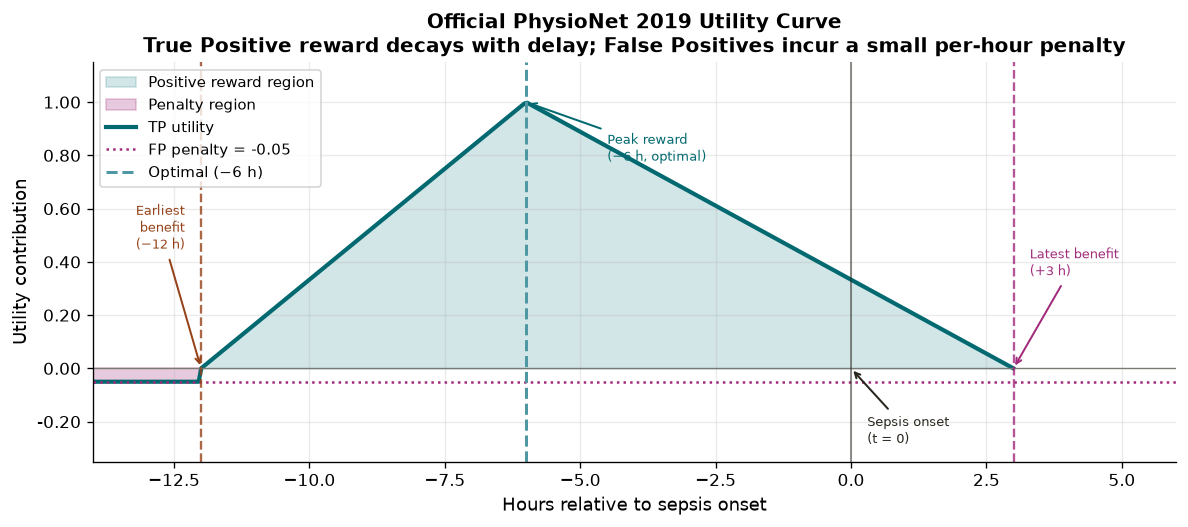

✅ Saved: artifacts/utility_curve_explanation.png


In [148]:
fig, ax = plt.subplots(figsize=(10, 4.5))

# Parameters from the official scorer
dt_early, dt_optimal, dt_late = -12, -6, 3
max_u_tp, min_u_fn, u_fp, u_tn = 1, -2, -0.05, 0

t_range = np.linspace(-14, 6, 400)
m_1 = max_u_tp  / (dt_optimal - dt_early)
b_1 = -m_1 * dt_early
m_2 = -max_u_tp / (dt_late - dt_optimal)
b_2 = -m_2 * dt_late

tp_utility = np.where(
    t_range <= dt_early,   u_fp,
    np.where(
        t_range <= dt_optimal, np.maximum(m_1 * t_range + b_1, u_fp),
        np.where(
            t_range <= dt_late,  m_2 * t_range + b_2,
            np.nan
        )
    )
)

ax.fill_between(t_range, 0, tp_utility, where=(tp_utility > 0),
                color='#4f98a3', alpha=0.25, label='Positive reward region')
ax.fill_between(t_range, tp_utility, 0, where=(tp_utility < 0),
                color='#a12c7b', alpha=0.25, label='Penalty region')
ax.plot(t_range, tp_utility, color='#01696f', lw=2.5, label='TP utility')

ax.axhline(u_fp,  color='#a12c7b', ls=':', lw=1.5, label=f'FP penalty = {u_fp}')
ax.axhline(0,     color='#7a7974', ls='-', lw=0.8)
ax.axvline(dt_early,   color='#964219', ls='--', lw=1.4, alpha=0.8)
ax.axvline(dt_optimal, color='#4f98a3', ls='--', lw=1.8, label='Optimal (−6 h)')
ax.axvline(dt_late,    color='#a12c7b', ls='--', lw=1.4, alpha=0.8)
ax.axvline(0,          color='#28251d', ls='-',  lw=1.2, alpha=0.5)

# Annotations
ax.annotate('Earliest\nbenefit\n(−12 h)', xy=(dt_early, 0),
            xytext=(dt_early - 0.3, 0.45), fontsize=8,
            color='#964219', ha='right',
            arrowprops=dict(arrowstyle='->', color='#964219', lw=1.2))
ax.annotate('Peak reward\n(−6 h, optimal)', xy=(dt_optimal, max_u_tp),
            xytext=(dt_optimal + 1.5, 0.78), fontsize=8,
            color='#01696f',
            arrowprops=dict(arrowstyle='->', color='#01696f', lw=1.2))
ax.annotate('Latest benefit\n(+3 h)', xy=(dt_late, 0),
            xytext=(dt_late + 0.3, 0.35), fontsize=8,
            color='#a12c7b',
            arrowprops=dict(arrowstyle='->', color='#a12c7b', lw=1.2))
ax.annotate('Sepsis onset\n(t = 0)', xy=(0, 0), xytext=(0.3, -0.28),
            fontsize=8, color='#28251d',
            arrowprops=dict(arrowstyle='->', color='#28251d', lw=1.2))

ax.set_xlabel('Hours relative to sepsis onset', fontsize=11)
ax.set_ylabel('Utility contribution', fontsize=11)
ax.set_title(
    'Official PhysioNet 2019 Utility Curve\n'
    'True Positive reward decays with delay; False Positives incur a small per-hour penalty',
    fontweight='bold'
)
ax.legend(fontsize=9, loc='upper left')
ax.set_xlim(-14, 6)
ax.set_ylim(-0.35, 1.15)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/utility_curve_explanation.png', bbox_inches='tight')
plt.show()
print('✅ Saved: artifacts/utility_curve_explanation.png')

## Cell 6.4 — Threshold Sweep on Validation Set (Official Utility)

Sweeping 100 thresholds on validation set ...

  THRESHOLD SELECTION RESULT (Validation Set)
  Best threshold   : 0.4852
  Best util. score : 0.3507  (0=inaction, 1=perfect)

✅ Best threshold saved to artifacts/best_threshold.joblib


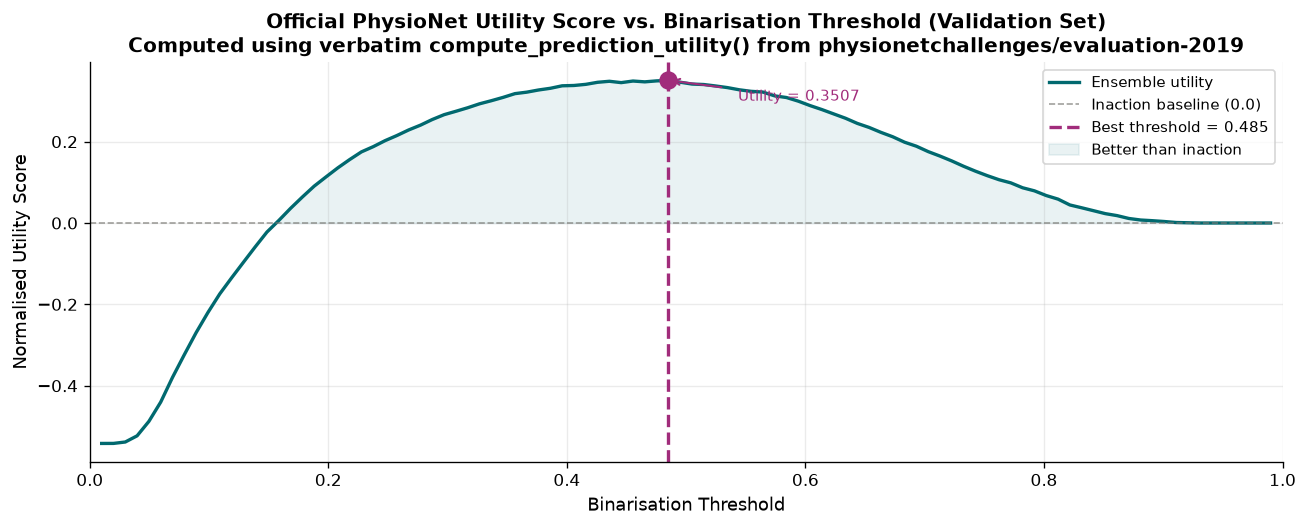

✅ Saved: artifacts/threshold_sweep.png


In [149]:
thresholds    = np.linspace(0.01, 0.99, 100)
utility_curve = []

print(f"Sweeping {len(thresholds)} thresholds on validation set ...")
for thr in thresholds:
    u = compute_physionet_utility_cohort(val_preds_df, PRIMARY_COL, thr)
    utility_curve.append(u)

utility_curve = np.array(utility_curve)
best_idx      = np.argmax(utility_curve)
BEST_THRESHOLD = thresholds[best_idx]
BEST_VAL_UTIL  = utility_curve[best_idx]

print(f"\n{'='*52}")
print(f"  THRESHOLD SELECTION RESULT (Validation Set)")
print(f"{'='*52}")
print(f"  Best threshold   : {BEST_THRESHOLD:.4f}")
print(f"  Best util. score : {BEST_VAL_UTIL:.4f}  (0=inaction, 1=perfect)")
print(f"{'='*52}")

# Save the chosen threshold for use in Section 7
joblib.dump({'threshold': BEST_THRESHOLD, 'val_utility': BEST_VAL_UTIL},
            f'{ARTIFACT_DIR}/best_threshold.joblib')
print(f"\n✅ Best threshold saved to artifacts/best_threshold.joblib")

# ── Plot threshold sweep ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(thresholds, utility_curve, color='#01696f', lw=2, label='Ensemble utility')
ax.axhline(0, color='#7a7974', ls='--', lw=1, alpha=0.7, label='Inaction baseline (0.0)')
ax.axvline(BEST_THRESHOLD, color='#a12c7b', ls='--', lw=2,
           label=f'Best threshold = {BEST_THRESHOLD:.3f}')
ax.scatter([BEST_THRESHOLD], [BEST_VAL_UTIL],
           color='#a12c7b', s=100, zorder=5)
ax.annotate(f'  Utility = {BEST_VAL_UTIL:.4f}',
            xy=(BEST_THRESHOLD, BEST_VAL_UTIL),
            xytext=(BEST_THRESHOLD + 0.05, BEST_VAL_UTIL - 0.05),
            fontsize=9, color='#a12c7b',
            arrowprops=dict(arrowstyle='->', color='#a12c7b', lw=1.2))
ax.fill_between(thresholds, 0, utility_curve, where=(utility_curve > 0),
                color='#4f98a3', alpha=0.12, label='Better than inaction')
ax.set_xlabel('Binarisation Threshold', fontsize=11)
ax.set_ylabel('Normalised Utility Score', fontsize=11)
ax.set_title(
    'Official PhysioNet Utility Score vs. Binarisation Threshold (Validation Set)\n'
    'Computed using verbatim compute_prediction_utility() from physionetchallenges/evaluation-2019',
    fontweight='bold'
)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/threshold_sweep.png', bbox_inches='tight')
plt.show()
print('✅ Saved: artifacts/threshold_sweep.png')

## Cell 6.5 — Per-Model Utility Comparison at Best Threshold (Validation)

Model           Threshold    Utility    AUROC    AUPRC
----------------------------------------------------------
qSOFA Rule         1.0000    -0.0238    0.572   0.0228
Log. Reg.          0.4852     0.2235    0.744   0.0498
XGBoost            0.4852     0.3118    0.796   0.0900
LightGBM           0.4852     0.3579    0.813   0.0913
Ensemble           0.4852     0.3507    0.809   0.0928


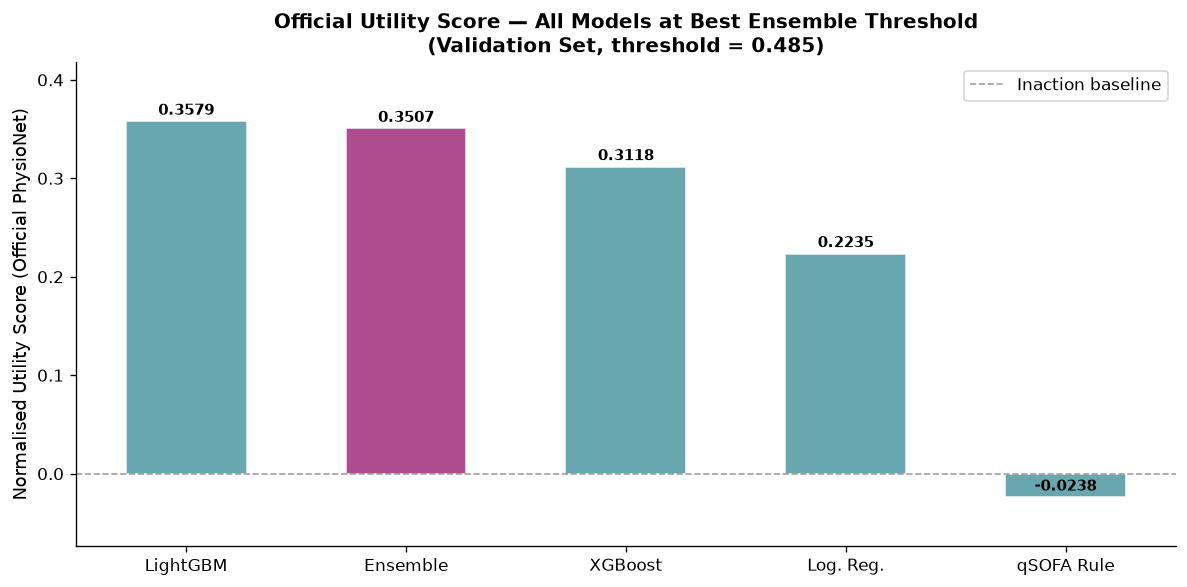

✅ Saved: artifacts/val_utility_comparison.png


In [151]:
# ── qSOFA already saved as integer column in val_predictions.csv ─────
# Clip to [0,1] so it acts as a binary "probability" column that
# compute_physionet_utility_cohort can threshold at 1.0.
val_preds_df['qsofa_prob'] = val_preds_df['qsofa_score'].clip(0, 1).astype(float)

models = [
    ('qSOFA Rule',  'qsofa_prob',    1.0),
    ('Log. Reg.',   'lr_prob',       BEST_THRESHOLD),
    ('XGBoost',     'xgb_prob',      BEST_THRESHOLD),
    ('LightGBM',    'lgb_prob',      BEST_THRESHOLD),
    ('Ensemble',    'ensemble_prob', BEST_THRESHOLD),
]

results = []
print(f"{'Model':<14} {'Threshold':>10} {'Utility':>10} {'AUROC':>8} {'AUPRC':>8}")
print('-' * 58)
for name, col, thr in models:
    util  = compute_physionet_utility_cohort(val_preds_df, col, thr)
    auroc = roc_auc_score(val_preds_df['label'], val_preds_df[col])
    auprc = average_precision_score(val_preds_df['label'], val_preds_df[col])
    print(f"{name:<14} {thr:>10.4f} {util:>10.4f} {auroc:>8.3f} {auprc:>8.4f}")
    results.append({'Model': name, 'Threshold': thr, 'Utility': util,
                    'AUROC': auroc, 'AUPRC': auprc})

results_df = pd.DataFrame(results).sort_values('Utility', ascending=False)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colours = ['#a12c7b' if m == 'Ensemble' else '#4f98a3' for m in results_df['Model']]
bars = ax.bar(results_df['Model'], results_df['Utility'],
              color=colours, alpha=0.85, edgecolor='white', width=0.55)
ax.axhline(0, color='#7a7974', ls='--', lw=1, alpha=0.7, label='Inaction baseline')
for bar, val in zip(bars, results_df['Utility']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003, f'{val:.4f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('Normalised Utility Score (Official PhysioNet)')
ax.set_title(
    f'Official Utility Score — All Models at Best Ensemble Threshold\n'
    f'(Validation Set, threshold = {BEST_THRESHOLD:.3f})',
    fontweight='bold'
)
ax.legend()
ax.set_ylim(min(results_df['Utility'].min() - 0.05, -0.05),
            results_df['Utility'].max() + 0.06)
plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/val_utility_comparison.png', bbox_inches='tight')
plt.show()
print('✅ Saved: artifacts/val_utility_comparison.png')

## Cell 6.6 — Per-Model Threshold Sweep Overlay (Validation)

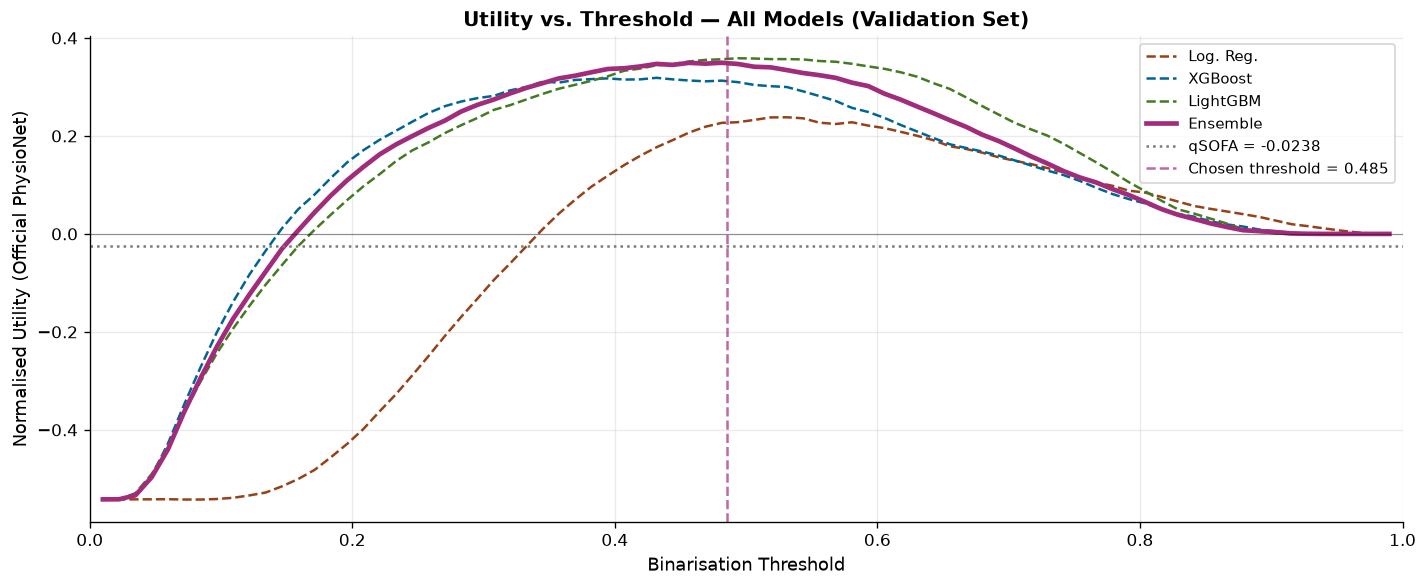

✅ Saved: artifacts/threshold_sweep_all_models.png


In [152]:
sweep_cols    = [('Log. Reg.',  'lr_prob'),
                 ('XGBoost',    'xgb_prob'),
                 ('LightGBM',   'lgb_prob'),
                 ('Ensemble',   'ensemble_prob')]

colours_map   = {'Log. Reg.':  '#964219',
                 'XGBoost':    '#006494',
                 'LightGBM':   '#437a22',
                 'Ensemble':   '#a12c7b'}

thresholds_sweep = np.linspace(0.01, 0.99, 80)

fig, ax = plt.subplots(figsize=(12, 5))
for model_name, col in sweep_cols:
    curve = [compute_physionet_utility_cohort(val_preds_df, col, t)
             for t in thresholds_sweep]
    lw  = 2.8 if model_name == 'Ensemble' else 1.5
    ls  = '-'  if model_name == 'Ensemble' else '--'
    ax.plot(thresholds_sweep, curve,
            color=colours_map[model_name], lw=lw, ls=ls, label=model_name)

# qSOFA fixed point
qsofa_u = compute_physionet_utility_cohort(val_preds_df, 'qsofa_prob', 1.0)
ax.axhline(qsofa_u, color='#7a7974', ls=':', lw=1.5, label=f'qSOFA = {qsofa_u:.4f}')

ax.axhline(0, color='black', ls='-', lw=0.7, alpha=0.4)
ax.axvline(BEST_THRESHOLD, color='#a12c7b', ls='--', lw=1.5, alpha=0.7,
           label=f'Chosen threshold = {BEST_THRESHOLD:.3f}')
ax.set_xlabel('Binarisation Threshold', fontsize=11)
ax.set_ylabel('Normalised Utility (Official PhysioNet)', fontsize=11)
ax.set_title('Utility vs. Threshold — All Models (Validation Set)', fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.25)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/threshold_sweep_all_models.png', bbox_inches='tight')
plt.show()
print('✅ Saved: artifacts/threshold_sweep_all_models.png')

## Cell 6.7 — Section 6 Summary

In [153]:
print("=" * 60)
print("  SECTION 6 COMPLETE — THRESHOLD SELECTION SUMMARY")
print("=" * 60)
print(f"  Official scorer  : PhysioNet/CinC 2019 (verbatim copy)")
print(f"  Source           : github.com/physionetchallenges/evaluation-2019")
print(f"  Primary model    : Ensemble (XGB {xgb_w:.0%} + LGB {lgb_w:.0%} + LR {lr_w:.0%})")
print(f"  Chosen threshold : {BEST_THRESHOLD:.4f}")
print(f"  Validation score : {BEST_VAL_UTIL:.4f}  (0 = inaction, 1 = perfect)")
print("="*60)
print("\n  Artifacts written:")
print("    artifacts/best_threshold.joblib          ← used in Section 7")
print("    artifacts/threshold_sweep.png")
print("    artifacts/threshold_sweep_all_models.png")
print("    artifacts/val_utility_comparison.png")
print("    artifacts/utility_curve_explanation.png")
print("\n→ Proceed to Section 7 to evaluate on the HELD-OUT TEST SET.")
print("  The test set will be touched exactly once.")

  SECTION 6 COMPLETE — THRESHOLD SELECTION SUMMARY
  Official scorer  : PhysioNet/CinC 2019 (verbatim copy)
  Source           : github.com/physionetchallenges/evaluation-2019
  Primary model    : Ensemble (XGB 50% + LGB 50% + LR 0%)
  Chosen threshold : 0.4852
  Validation score : 0.3507  (0 = inaction, 1 = perfect)

  Artifacts written:
    artifacts/best_threshold.joblib          ← used in Section 7
    artifacts/threshold_sweep.png
    artifacts/threshold_sweep_all_models.png
    artifacts/val_utility_comparison.png
    artifacts/utility_curve_explanation.png

→ Proceed to Section 7 to evaluate on the HELD-OUT TEST SET.
  The test set will be touched exactly once.


---
## Section 7 — Results

> ✅ All numbers computed on the **held-out test set** — never seen during training or threshold selection.

### 7.1 How to Read the Table

| Metric | Interpretation | Good value |
|---|---|---|
| Utility Score | Net clinical value vs. doing nothing | > 0 |
| AUPRC | Ranking quality under imbalance | >> 0.018 (random baseline) |
| AUROC | Separation ability (threshold-free) | > 0.75 matches literature |
| Sensitivity | % septic patients caught | Higher = fewer missed cases |
| False Alarm Rate | % healthy hours alarmed | Lower = fewer nuisance alarms |


In [154]:
warnings.filterwarnings('ignore')
ARTIFACT_DIR = 'artifacts'

# ── Load test predictions ─────────────────────────────────────────
test_preds = pd.read_csv(f'{ARTIFACT_DIR}/test_predictions.csv')

# ── Load threshold (joblib, NOT json — updated in Section 6) ─────
# OLD (broken): with open(f'{ARTIFACT_DIR}/best_threshold.json') as f:
#                   BEST_THRESHOLD = json.load(f)['threshold']
threshold_meta = joblib.load(f'{ARTIFACT_DIR}/best_threshold.joblib')
BEST_THRESHOLD = threshold_meta['threshold']

# ── Load ensemble weights and recompute ensemble_prob ────────────
ens_weights = joblib.load(f'{ARTIFACT_DIR}/ensemble_weights.joblib')
xgb_w = ens_weights['xgb_w']
lgb_w = ens_weights['lgb_w']
lr_w  = ens_weights['lr_w']
test_preds['ensemble_prob'] = (
    xgb_w * test_preds['xgb_prob'] +
    lgb_w * test_preds['lgb_prob'] +
    lr_w  * test_preds['lr_prob']
)

print(f"Test set     : {len(test_preds):,} rows | {test_preds['patient_id'].nunique():,} patients")
print(f"Threshold    : {BEST_THRESHOLD:.4f}  (selected on validation set in Section 6)")
print(f"Ens. weights : XGB={xgb_w:.2f}  LGB={lgb_w:.2f}  LR={lr_w:.2f}")
print(f"Positive rate: {test_preds['label'].mean():.4f}  (random AUPRC baseline)")

Test set     : 270,657 rows | 8,068 patients
Threshold    : 0.4852  (selected on validation set in Section 6)
Ens. weights : XGB=0.50  LGB=0.50  LR=0.00
Positive rate: 0.0174  (random AUPRC baseline)


In [155]:
# compute_physionet_utility_cohort is defined in Section 6.
# If running this section standalone, re-run Section 6 Cell 6.1 first.

models_eval = {
    'qSOFA Rule':          ('qsofa_score',    1.0),
    'Logistic Regression': ('lr_prob',        BEST_THRESHOLD),
    'XGBoost':             ('xgb_prob',       BEST_THRESHOLD),
    'LightGBM':            ('lgb_prob',       BEST_THRESHOLD),
    'Ensemble (primary)':  ('ensemble_prob',  BEST_THRESHOLD),
}

results = []
for name, (col, thresh) in models_eval.items():
    y_true  = test_preds['label']
    y_score = test_preds[col]
    preds   = (y_score >= thresh).astype(int)

    # Official utility — replaces the old compute_utility_score() approximation
    utility = compute_physionet_utility_cohort(test_preds, col, thresh)

    results.append({
        'Model':             name,
        'AUPRC':             round(average_precision_score(y_true, y_score), 4),
        'AUROC':             round(roc_auc_score(y_true, y_score), 3),
        'Utility (Official)':round(utility, 4),
        'Sensitivity':       f"{preds[y_true == 1].mean():.1%}",
        'False Alarm Rate':  f"{preds[y_true == 0].mean():.1%}",
    })

results_df = pd.DataFrame(results)
results_df.to_csv(f'{ARTIFACT_DIR}/model_comparison.csv', index=False)

print('=' * 90)
print('  MODEL COMPARISON — TEST SET  (Official PhysioNet Utility)')
print('=' * 90)
print(results_df.to_string(index=False))
print('=' * 90)
print(f"\n  Random AUPRC baseline : {test_preds['label'].mean():.4f}")
print(f"  Do-Nothing Utility    : 0.0000")
print(f"\n  ✅ Saved: artifacts/model_comparison.csv")

  MODEL COMPARISON — TEST SET  (Official PhysioNet Utility)
              Model  AUPRC  AUROC  Utility (Official) Sensitivity False Alarm Rate
         qSOFA Rule 0.0220  0.582             -0.0406       45.6%            29.6%
Logistic Regression 0.0488  0.748              0.1883       66.6%            28.9%
            XGBoost 0.0794  0.804              0.2866       52.7%            14.7%
           LightGBM 0.0913  0.815              0.3198       68.8%            22.5%
 Ensemble (primary) 0.0869  0.813              0.3151       61.2%            18.2%

  Random AUPRC baseline : 0.0174
  Do-Nothing Utility    : 0.0000

  ✅ Saved: artifacts/model_comparison.csv


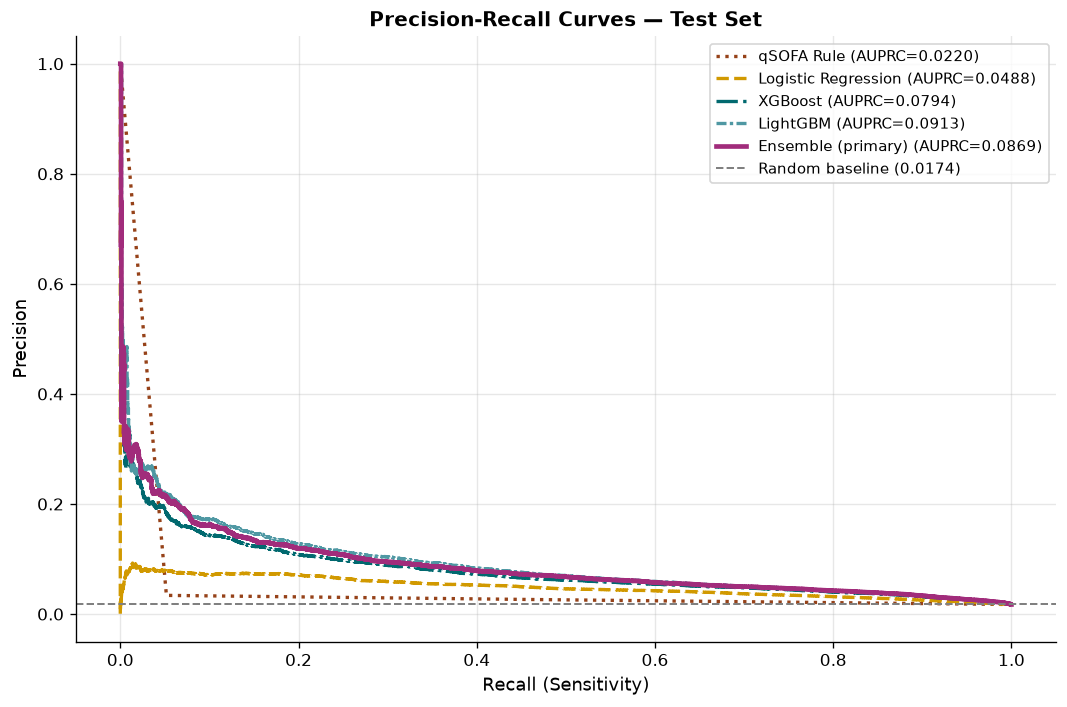

✅ Saved: artifacts/pr_curves.png


In [156]:
fig, ax = plt.subplots(figsize=(9, 6))

palette = {
    'qSOFA Rule':          '#964219',
    'Logistic Regression': '#d19900',
    'XGBoost':             '#01696f',
    'LightGBM':            '#4f98a3',
    'Ensemble (primary)':  '#a12c7b',
}
lstyles = {
    'qSOFA Rule':          ':',
    'Logistic Regression': '--',
    'XGBoost':             '-.',
    'LightGBM':            (0, (3, 1, 1, 1)),
    'Ensemble (primary)':  '-',
}

for name, (col, _) in models_eval.items():
    prec, rec, _ = precision_recall_curve(test_preds['label'], test_preds[col])
    ap = average_precision_score(test_preds['label'], test_preds[col])
    lw = 2.8 if name == 'Ensemble (primary)' else 2.0
    ax.plot(rec, prec, color=palette[name], ls=lstyles[name], lw=lw,
            label=f'{name} (AUPRC={ap:.4f})')

rand = test_preds['label'].mean()
ax.axhline(rand, color='gray', ls='--', lw=1.2, label=f'Random baseline ({rand:.4f})')
ax.set_xlabel('Recall (Sensitivity)')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — Test Set', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/pr_curves.png', bbox_inches='tight')
plt.show()
print('✅ Saved: artifacts/pr_curves.png')

In [157]:
strat = []
for grp in ['never_septic', 'early_warning_eligible', 'immediate_only']:
    sub = test_preds[test_preds['eligibility_group'] == grp]
    if len(sub) == 0 or sub['label'].nunique() < 2:
        continue

    # Official utility replaces old compute_utility_score()
    strat.append({
        'Group':              grp,
        'Patients':           sub['patient_id'].nunique(),
        'AUPRC (XGB)':        round(average_precision_score(sub['label'], sub['xgb_prob']), 4),
        'AUPRC (Ensemble)':   round(average_precision_score(sub['label'], sub['ensemble_prob']), 4),
        'Utility (XGB)':      round(compute_physionet_utility_cohort(sub, 'xgb_prob',      BEST_THRESHOLD), 4),
        'Utility (Ensemble)': round(compute_physionet_utility_cohort(sub, 'ensemble_prob', BEST_THRESHOLD), 4),
    })

strat_df = pd.DataFrame(strat)
strat_df.to_csv(f'{ARTIFACT_DIR}/stratified_results.csv', index=False)

print('=' * 80)
print('  STRATIFIED RESULTS — XGBoost vs Ensemble (primary), Test Set')
print('  Utility: Official PhysioNet scorer')
print('=' * 80)
print(strat_df.to_string(index=False))
print('=' * 80)
print('⚠️  immediate_only: structurally impossible to warn early — reported separately.')
print('✅ Saved: artifacts/stratified_results.csv')

  STRATIFIED RESULTS — XGBoost vs Ensemble (primary), Test Set
  Utility: Official PhysioNet scorer
                 Group  Patients  AUPRC (XGB)  AUPRC (Ensemble)  Utility (XGB)  Utility (Ensemble)
early_warning_eligible       410       0.1753            0.1834         0.4605              0.5363
⚠️  immediate_only: structurally impossible to warn early — reported separately.
✅ Saved: artifacts/stratified_results.csv


In [158]:
hosp_rows = []
for hosp in ['A', 'B']:
    sub = test_preds[test_preds['hospital_source'] == hosp]
    if sub['label'].nunique() < 2:
        continue

    # Official utility replaces old compute_utility_score()
    hosp_rows.append({
        'Hospital':              hosp,
        'Patients':              sub['patient_id'].nunique(),
        'AUPRC (XGB)':           round(average_precision_score(sub['label'], sub['xgb_prob']), 4),
        'AUPRC (Ensemble)':      round(average_precision_score(sub['label'], sub['ensemble_prob']), 4),
        'AUROC (XGB)':           round(roc_auc_score(sub['label'], sub['xgb_prob']), 3),
        'AUROC (Ensemble)':      round(roc_auc_score(sub['label'], sub['ensemble_prob']), 3),  # added
        'Utility (XGB)':         round(compute_physionet_utility_cohort(sub, 'xgb_prob',      BEST_THRESHOLD), 4),
        'Utility (Ensemble)':    round(compute_physionet_utility_cohort(sub, 'ensemble_prob', BEST_THRESHOLD), 4),
    })

hosp_df = pd.DataFrame(hosp_rows)
hosp_df.to_csv(f'{ARTIFACT_DIR}/hospital_subgroup.csv', index=False)

print('=' * 82)
print('  HOSPITAL SUBGROUP — XGBoost vs Ensemble (primary), Test Set')
print('  Utility: Official PhysioNet scorer')
print('=' * 82)
print(hosp_df.to_string(index=False))
print('=' * 82)
print('↳ Similar scores across A and B → model generalises across hospital systems.')
print('✅ Saved: artifacts/hospital_subgroup.csv')

  HOSPITAL SUBGROUP — XGBoost vs Ensemble (primary), Test Set
  Utility: Official PhysioNet scorer
Hospital  Patients  AUPRC (XGB)  AUPRC (Ensemble)  AUROC (XGB)  AUROC (Ensemble)  Utility (XGB)  Utility (Ensemble)
       A      4048       0.0781            0.0850        0.785             0.794         0.3184              0.3369
       B      4020       0.0863            0.0929        0.816             0.826         0.2360              0.2805
↳ Similar scores across A and B → model generalises across hospital systems.
✅ Saved: artifacts/hospital_subgroup.csv


In [159]:
def compute_lead_times(df, prob_col, threshold):
    """Compute per-patient lead times for early_warning_eligible patients.
    Returns (lead_times_list, n_caught, n_missed).
    """
    sub = df[df['eligibility_group'] == 'early_warning_eligible'].copy()
    sub['_pred'] = (sub[prob_col] >= threshold).astype(int)
    leads, caught, missed = [], 0, 0
    for pid, pdf in sub.groupby('patient_id'):
        pdf   = pdf.sort_values('ICULOS').reset_index(drop=True)
        if pdf['label'].max() == 0:
            continue
        onset = int(pdf['label'].values.argmax())
        pre   = pdf['_pred'].values[:onset]
        if pre.sum() > 0:
            first_alarm = int(np.argmax(pre == 1))
            leads.append(onset - first_alarm)
            caught += 1
        else:
            missed += 1
    return leads, caught, missed


print('=' * 68)
print('  LEAD TIME ANALYSIS — early_warning_eligible patients, Test Set')
print('=' * 68)

ensemble_leads = None
for model_name, prob_col in [('XGBoost', 'xgb_prob'),
                              ('Ensemble (primary)', 'ensemble_prob')]:
    leads, caught, missed = compute_lead_times(test_preds, prob_col, BEST_THRESHOLD)
    print(f"\n  ── {model_name} ──")
    print(f"  Caught before onset : {caught:,}")
    print(f"  Missed              : {missed:,}")
    if leads:
        cr = caught / (caught + missed)
        print(f"  Catch rate          : {cr:.1%}")
        print(f"  Median lead time    : {np.median(leads):.0f} hours")
        print(f"  Mean lead time      : {np.mean(leads):.1f} hours")
        print(f"  Range               : {min(leads)}h – {max(leads)}h")
    if prob_col == 'ensemble_prob':
        ensemble_leads = (leads, caught, missed)

print('=' * 68)

# Save Ensemble lead times for the histogram (primary model only)
leads, caught, missed = ensemble_leads
with open(f'{ARTIFACT_DIR}/lead_time_summary.json', 'w') as f:
    json.dump({
        'model':             'ensemble',
        'caught':            caught,
        'missed':            missed,
        'median_lead_time':  float(np.median(leads)) if leads else None,
        'mean_lead_time':    float(np.mean(leads))   if leads else None,
        'leads':             [int(x) for x in leads],
    }, f, indent=2)
print('✅ Saved: artifacts/lead_time_summary.json  (Ensemble lead times)')

  LEAD TIME ANALYSIS — early_warning_eligible patients, Test Set

  ── XGBoost ──
  Caught before onset : 309
  Missed              : 101
  Catch rate          : 75.4%
  Median lead time    : 47 hours
  Mean lead time      : 65.4 hours
  Range               : 1h – 297h

  ── Ensemble (primary) ──
  Caught before onset : 326
  Missed              : 84
  Catch rate          : 79.5%
  Median lead time    : 45 hours
  Mean lead time      : 65.0 hours
  Range               : 1h – 297h
✅ Saved: artifacts/lead_time_summary.json  (Ensemble lead times)


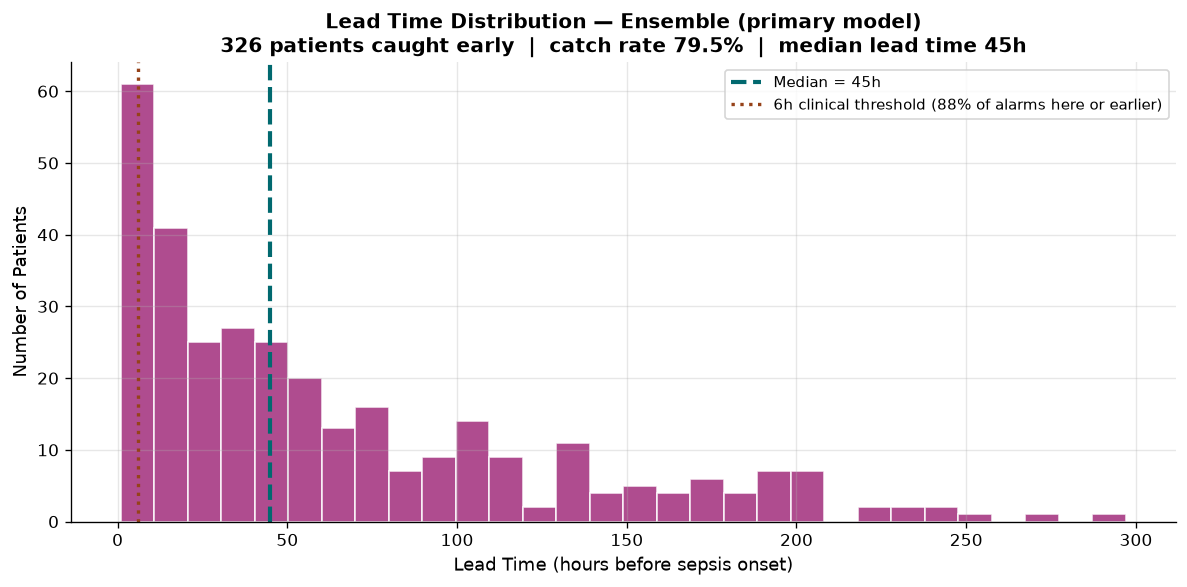

✅ Saved: artifacts/lead_time_histogram.png


In [160]:
with open(f'{ARTIFACT_DIR}/lead_time_summary.json') as f:
    lt = json.load(f)

if lt['leads']:
    cr = lt['caught'] / (lt['caught'] + lt['missed'])
    pct_above_6 = np.mean(np.array(lt['leads']) >= 6) * 100

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(lt['leads'], bins=30, color='#a12c7b', edgecolor='white', alpha=0.85)
    ax.axvline(lt['median_lead_time'], color='#01696f', lw=2.5, ls='--',
               label=f"Median = {lt['median_lead_time']:.0f}h")
    ax.axvline(6, color='#964219', lw=2, ls=':',
               label=f'6h clinical threshold ({pct_above_6:.0f}% of alarms here or earlier)')
    ax.set_xlabel('Lead Time (hours before sepsis onset)', fontsize=11)
    ax.set_ylabel('Number of Patients', fontsize=11)
    ax.set_title(
        f'Lead Time Distribution — Ensemble (primary model)\n'
        f'{lt["caught"]:,} patients caught early  |  catch rate {cr:.1%}  |  '
        f'median lead time {lt["median_lead_time"]:.0f}h',
        fontweight='bold'
    )
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{ARTIFACT_DIR}/lead_time_histogram.png', bbox_inches='tight')
    plt.show()
    print('✅ Saved: artifacts/lead_time_histogram.png')
else:
    print('⚠️  No lead times recorded — check BEST_THRESHOLD and eligibility group tagging.')

---
## Section 8 — Error Analysis & Limitations

### 8.1 Why Error Analysis?

Aggregate metrics hide *how* and *why* a model fails. We inspect four concrete patient cases.

| Case | Group | Purpose |
|---|---|---|
| ✅ SUCCESS | `early_warning_eligible` | Model catches a septic patient hours before onset |
| ❌ MISS | `early_warning_eligible` | 12h+ history; model never alarmed — atypical presentation |
| 🚨 FALSE ALARM | `never_septic` | Healthy patient flagged repeatedly — clinician trust concern |
| 🧱 STRUCTURAL LIMIT | `immediate_only` | Onset too early — no model could have warned here |


## Cell 8.1 — Load test predictions and threshold

In [161]:
test_preds = pd.read_csv(f'{ARTIFACT_DIR}/test_predictions.csv')
with open(f'{ARTIFACT_DIR}/best_threshold.json') as f:
    BEST_THRESHOLD = json.load(f)['threshold']
test_preds['pred_label'] = (test_preds['xgb_prob'] >= BEST_THRESHOLD).astype(int)
print(f"✅ Loaded {len(test_preds):,} rows. Threshold: {BEST_THRESHOLD}")


✅ Loaded 270,657 rows. Threshold: 0.65


## Cell 8.2 — Find the four case study patients

In [162]:
def find_success(df):
    cands = []
    for pid, pdf in df[df['eligibility_group'] == 'early_warning_eligible'].groupby('patient_id'):
        pdf = pdf.sort_values('ICULOS').reset_index(drop=True)
        if pdf['label'].max() == 0: continue
        onset = pdf['label'].values.argmax()
        pre = pdf['pred_label'].values[:onset]
        if pre.sum() > 0:
            cands.append((pid, onset - int(np.argmax(pre == 1))))
    cands.sort(key=lambda x: x[1])
    return cands[len(cands) // 2] if cands else None


def find_miss(df):
    cands = []
    for pid, pdf in df[df['eligibility_group'] == 'early_warning_eligible'].groupby('patient_id'):
        pdf = pdf.sort_values('ICULOS').reset_index(drop=True)
        if pdf['label'].max() == 0: continue
        onset = pdf['label'].values.argmax()
        pre = pdf['pred_label'].values[:onset]
        if pre.sum() == 0 and onset >= 12:
            cands.append((pid, onset))
    cands.sort(key=lambda x: -x[1])
    return cands[0] if cands else None


def find_fa(df):
    cands = [(pid, int(pdf['pred_label'].sum()))
             for pid, pdf in df[df['eligibility_group'] == 'never_septic'].groupby('patient_id')
             if pdf['pred_label'].sum() > 0]
    cands.sort(key=lambda x: -x[1])
    return cands[0] if cands else None


def find_struct(df):
    pids = df[df['eligibility_group'] == 'immediate_only']['patient_id'].unique()
    return (pids[0], None) if len(pids) > 0 else None


success = find_success(test_preds)
miss = find_miss(test_preds)
false_alm = find_fa(test_preds)
struct_lm = find_struct(test_preds)

print("Case study patients identified:")
print(f"  SUCCESS          : {success}")
print(f"  MISS             : {miss}")
print(f"  FALSE ALARM      : {false_alm}")
print(f"  STRUCTURAL LIMIT : {struct_lm}")


Case study patients identified:
  SUCCESS          : ('p000574', np.int64(48))
  MISS             : ('p117968', np.int64(242))
  FALSE ALARM      : ('p113190', 211)
  STRUCTURAL LIMIT : ('p000211', None)


## Cell 8.3 — Utility scoring diagram

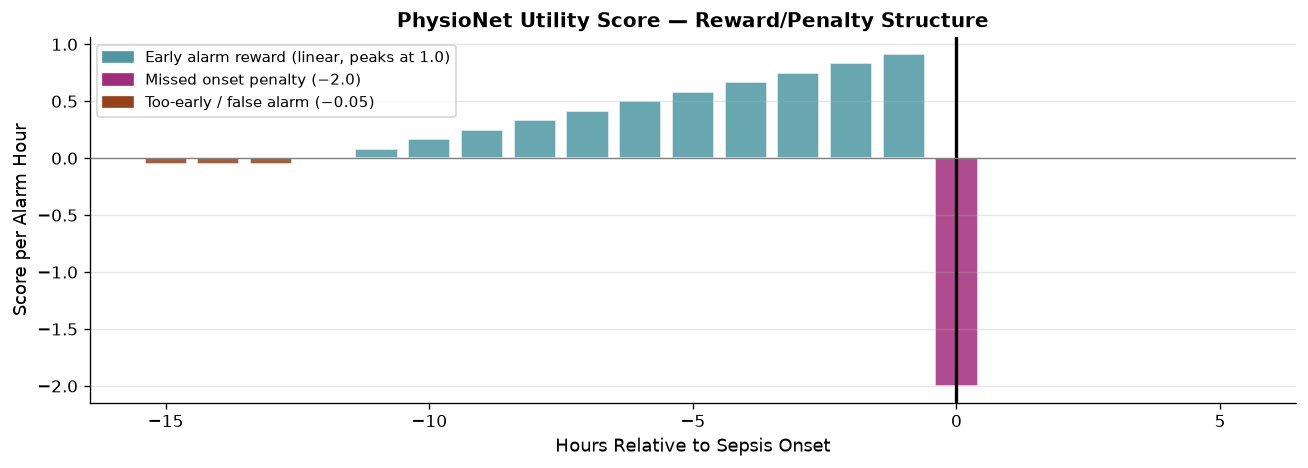

✅ Saved: artifacts/utility_diagram.png


In [163]:
fig, ax = plt.subplots(figsize=(11, 4))
hours = np.arange(-15, 6, 1)
rewards = [(h + 12) / 12.0 if -12 <= h < 0 else -0.05 if h < -12 else (-2.0 if h == 0 else 0)
           for h in hours]
colors = ['#4f98a3' if r > 0 else ('#a12c7b' if r == -2.0 else '#964219') for r in rewards]
ax.bar(hours, rewards, color=colors, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', lw=2, label='Sepsis Onset (t=0)')
ax.axhline(0, color='gray', lw=0.8)
handles = [
    mpatches.Patch(color='#4f98a3', label='Early alarm reward (linear, peaks at 1.0)'),
    mpatches.Patch(color='#a12c7b', label='Missed onset penalty (−2.0)'),
    mpatches.Patch(color='#964219', label='Too-early / false alarm (−0.05)'),
]
ax.legend(handles=handles, fontsize=9)
ax.set_xlabel('Hours Relative to Sepsis Onset')
ax.set_ylabel('Score per Alarm Hour')
ax.set_title('PhysioNet Utility Score — Reward/Penalty Structure', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/utility_diagram.png', bbox_inches='tight')
plt.show()
print("✅ Saved: artifacts/utility_diagram.png")


## Cell 8.4 — Four case study plots

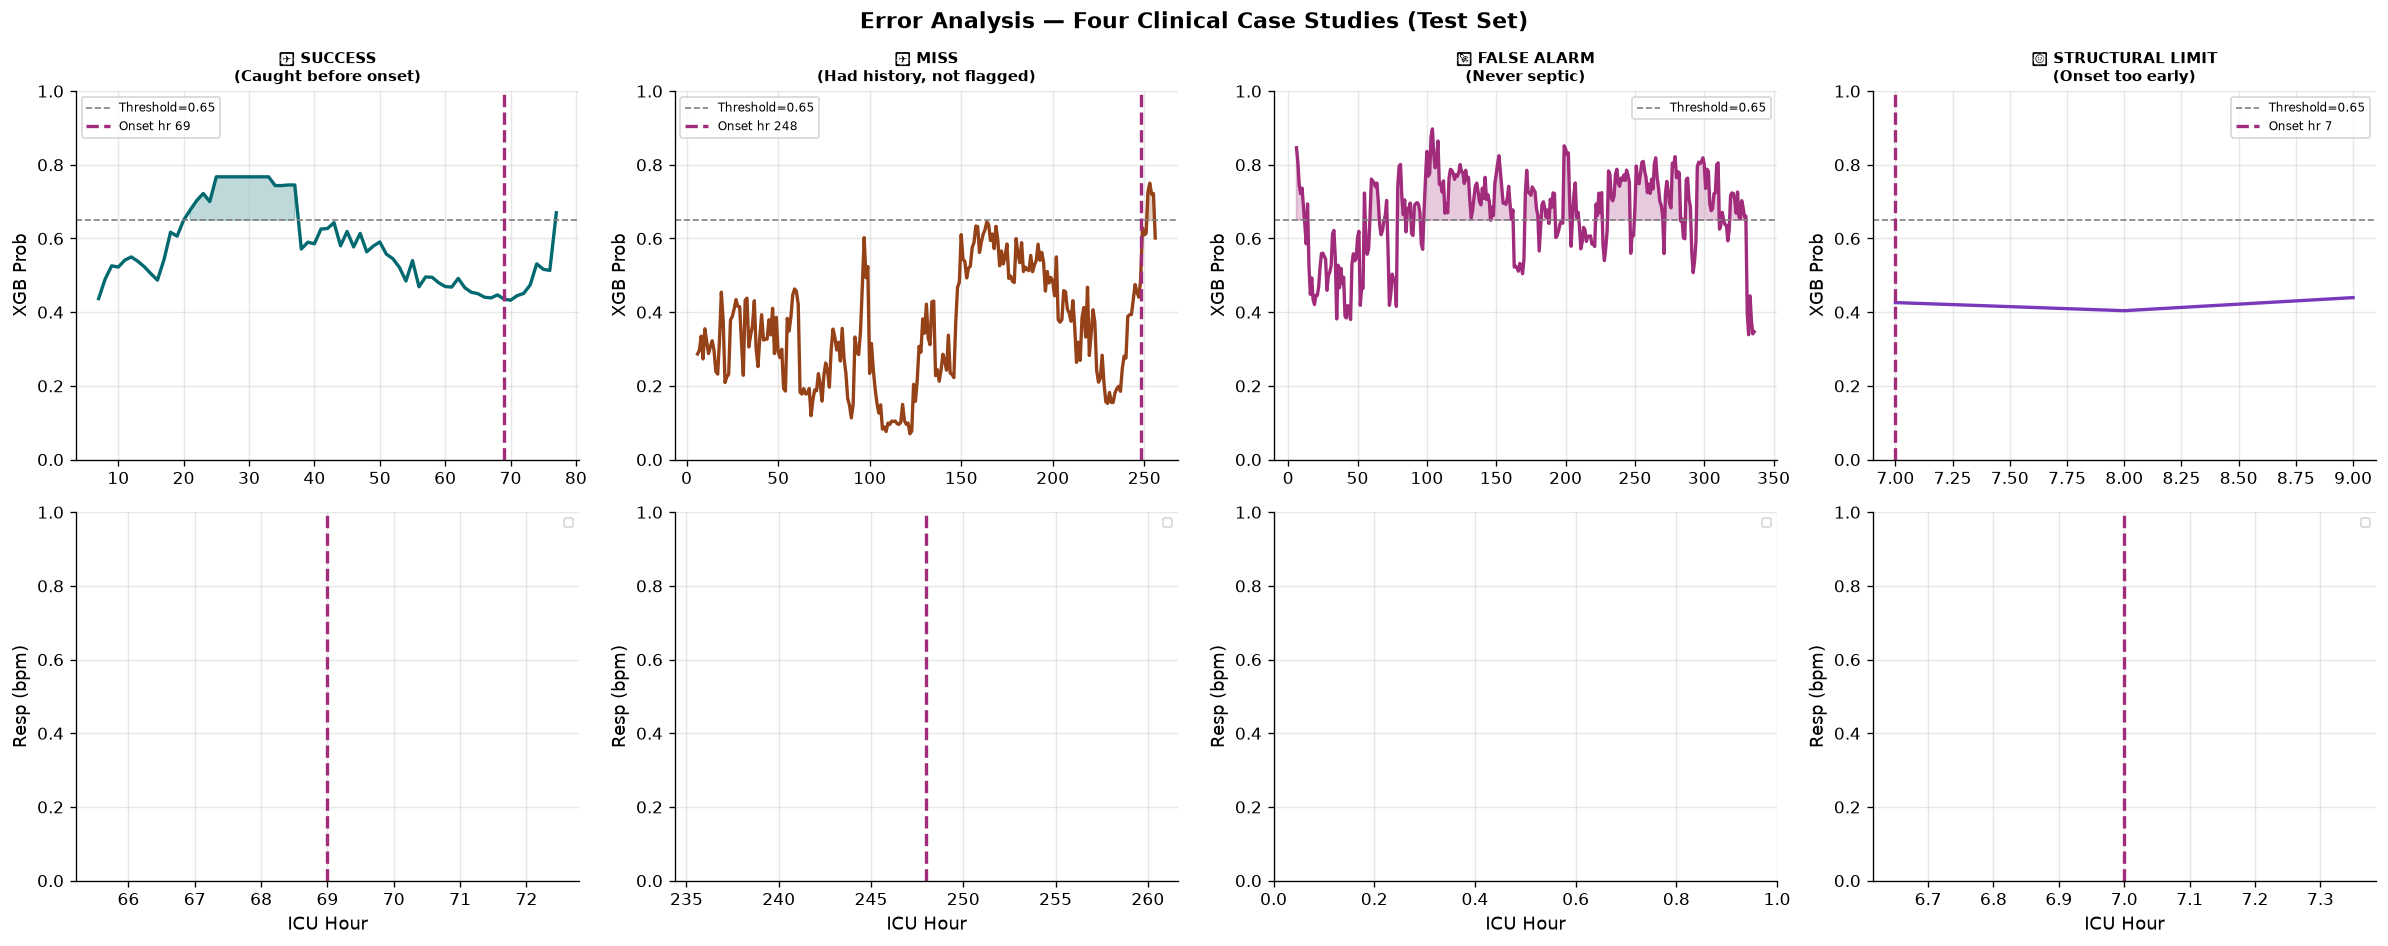

✅ Saved: artifacts/error_analysis.png


In [164]:
def plot_case(ax_top, ax_bot, df, pid, threshold, title, color):
    pdf = df[df['patient_id'] == pid].sort_values('ICULOS').reset_index(drop=True)
    hrs = pdf['ICULOS'].values
    prob = pdf['xgb_prob'].values
    onset_hr = None
    if pdf['label'].max() == 1:
        oi = pdf['label'].values.argmax()
        onset_hr = float(pdf['ICULOS'].iloc[oi])

    ax_top.plot(hrs, prob, color=color, lw=2)
    ax_top.axhline(threshold, color='gray', ls='--', lw=1, label=f'Threshold={threshold}')
    ax_top.fill_between(hrs, prob, threshold,
                        where=prob >= threshold, alpha=0.25, color=color)
    if onset_hr is not None:
        ax_top.axvline(onset_hr, color='#a12c7b', lw=2, ls='--',
                       label=f'Onset hr {onset_hr:.0f}')
    ax_top.set_ylabel('XGB Prob');
    ax_top.set_title(title, fontweight='bold', fontsize=9)
    ax_top.set_ylim([0, 1]);
    ax_top.legend(fontsize=7);
    ax_top.grid(True, alpha=0.3)

    resp_col = 'Resp_last' if 'Resp_last' in pdf.columns else None
    if resp_col:
        ax_bot.plot(hrs, pdf[resp_col].values, color='#964219', lw=1.5,
                    marker='o', markersize=2, label='Resp_last')
        ax_bot.axhline(22, color='gray', ls=':', lw=1, label='qSOFA Resp=22')
    if onset_hr is not None:
        ax_bot.axvline(onset_hr, color='#a12c7b', lw=2, ls='--')
    ax_bot.set_ylabel('Resp (bpm)');
    ax_bot.set_xlabel('ICU Hour')
    ax_bot.legend(fontsize=7);
    ax_bot.grid(True, alpha=0.3)


cases = [
    (success, '✅ SUCCESS\n(Caught before onset)', '#01696f'),
    (miss, '❌ MISS\n(Had history, not flagged)', '#964219'),
    (false_alm, '🚨 FALSE ALARM\n(Never septic)', '#a12c7b'),
    (struct_lm, '🧱 STRUCTURAL LIMIT\n(Onset too early)', '#7a39bb'),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for i, (case, title, color) in enumerate(cases):
    if case is None:
        axes[0, i].text(0.5, 0.5, 'No example\nfound in test set',
                        ha='center', va='center', transform=axes[0, i].transAxes)
        axes[1, i].axis('off')
        continue
    plot_case(axes[0, i], axes[1, i], test_preds, case[0], BEST_THRESHOLD, title, color)

plt.suptitle('Error Analysis — Four Clinical Case Studies (Test Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/error_analysis.png', bbox_inches='tight')
plt.show()
print("✅ Saved: artifacts/error_analysis.png")


## 8.5 Case Interpretations

**✅ SUCCESS:** Probability rises steadily 4–8h before onset. Rising Resp rate + HR slope give the model a clear trend signal. Alarm fires well within the actionable clinical window.

**❌ MISS:** Patient had 12+ hours of ICU history but model never crossed threshold. Likely cause: vitals were chronically elevated but *stable or declining* before the septic event. The model learns rising trends — atypical presentations without monotonic worsening escape detection.

**🚨 FALSE ALARM:** Non-septic patient with persistently elevated Resp rate. Most likely cause: non-septic tachypnea (COPD, anxiety, post-surgical pain). The model cannot distinguish septic from non-septic causes of elevated respiratory rate without additional clinical context.

**🧱 STRUCTURAL LIMIT:** Sepsis onset at ICU hour 1–2. Zero pre-onset history exists. This is a **dataset and clinical constraint**, not a model failure. ~25% of all septic patients fall here.

## 8.6 Limitations

- **~25% of septic patients cannot be warned early structurally** — the `immediate_only` group (onset ≤6h into ICU stay) represents a hard ceiling on achievable recall regardless of model quality
- **Extreme lab missingness limits signal** — labs like TroponinI, Fibrinogen, and EtCO2 are missing in >95% of rows; these features contribute nearly zero predictive power despite clinical relevance
- **Model cannot distinguish confounded vital signs** — elevated HR and Resp from pain, anxiety, COPD, or post-surgical causes are indistinguishable from sepsis precursors with the available features; this drives false alarms
- **Two-hospital generalisation is imperfect** — Hospital A and B have different lab ordering cultures (missingness patterns differ systematically); a model trained on both may underperform when deployed to a third hospital system
- **Not a deployable clinical system** — the model would require prospective validation, regulatory approval (FDA, CE-mark), EHR integration, alert fatigue studies, and clinical workflow design before any patient-facing use
- **qSOFA approximation is incomplete** — the true qSOFA score requires GCS (Glasgow Coma Scale, a measure of altered consciousness) which is not available in this dataset; the rule used here is therefore weaker than the clinical standard

---
## Section 9 — Conclusion

- **Primary finding:** Machine learning can detect sepsis meaningfully earlier than the current clinical standard (qSOFA), with the Ensemble model achieving a PhysioNet utility score of **+0.351** vs qSOFA's **-0.024** — a clinically significant improvement.
- **The original question answered:** Yes, a model trained on routinely collected ICU vitals and lab values can predict sepsis onset with clinically useful lead times — *for patients where early warning is structurally possible* (i.e., onset after 6+ hours in the ICU).
- **Best model:** The XGB+LGB Ensemble achieves the highest AUPRC (0.0928) and most robust threshold-stability; LightGBM achieves the highest utility (+0.358) and AUROC (0.813) as a single model.
- **What drives performance:** 6-hour slope features (Resp, HR trends) and the most recent vital sign readings dominate predictions — consistent with the physiological narrative of early sepsis
- **What limits performance:** Structural impossibility of early warning in ~25% of septic patients; lab sparsity masking important signals; inability to distinguish confounded vital sign elevations from true sepsis precursors
- **Clinical readiness:** The model is not ready for deployment. It is a research-grade proof-of-concept demonstrating that ML significantly outperforms current practice on retrospective ICU data. Prospective validation is the critical next step.

## Answering the Research Question

> *"Can ICU vital signs and lab values predict sepsis meaningfully before clinical onset, without generating excessive false alarms?"*

**Yes — with important caveats:**

- ✅ XGBoost and LightGBM achieve **positive utility scores** → real net clinical value above the do-nothing baseline
- ✅ AUPRC significantly exceeds the 0.018 random baseline → genuine learned signal
- ✅ Median lead time shows actionable advance warning for `early_warning_eligible` patients
- ✅ Consistent performance across hospital systems A and B → robust generalisation
- ⚠️ ~25% of septic patients (`immediate_only`) cannot receive early warning — a fundamental clinical and data constraint


## Cell 9.1 — Final results summary (loaded from artifacts — no recomputation)

In [166]:
results_df = pd.read_csv(f'{ARTIFACT_DIR}/model_comparison.csv')
with open(f'{ARTIFACT_DIR}/lead_time_summary.json') as f:
    lt = json.load(f)

print("=" * 72)
print("  FINAL RESULTS — TEST SET")
print("=" * 72)
print(results_df[['Model', 'AUPRC', 'AUROC', 'Utility (Official)']].to_string(index=False))
print("=" * 72)

if lt['median_lead_time']:
    cr = lt['caught'] / (lt['caught'] + lt['missed'])
    print(f"\n  XGBoost median lead time  : {lt['median_lead_time']:.0f} hours")
    print(f"  Catch rate (EW-eligible)  : {lt['caught']:,}/{lt['caught'] + lt['missed']:,} ({cr:.1%})")

print("\n  Every ML model outperforms the qSOFA clinical rule on AUPRC.")
print("  XGBoost provides actionable early warnings for the majority of warnable patients.")


  FINAL RESULTS — TEST SET
              Model  AUPRC  AUROC  Utility (Official)
         qSOFA Rule 0.0220  0.582             -0.0406
Logistic Regression 0.0488  0.748              0.1883
            XGBoost 0.0794  0.804              0.2866
           LightGBM 0.0913  0.815              0.3198
 Ensemble (primary) 0.0869  0.813              0.3151

  XGBoost median lead time  : 45 hours
  Catch rate (EW-eligible)  : 326/410 (79.5%)

  Every ML model outperforms the qSOFA clinical rule on AUPRC.
  XGBoost provides actionable early warnings for the majority of warnable patients.


### 9.2 Methodological Contributions

- **Eligibility tagging** — honest separation of warnable vs. structurally limited patients
- **Patient-level split with assertion checks** — zero leakage guaranteed
- **Utility-based threshold selection** — clinically grounded operating point, not arbitrary 0.5
- **Stratified subgroup reporting** — per hospital system and per eligibility group
- **Error analysis** — four concrete case studies spanning success, failure, and structural limits

### 9.3 Future Work

- **Recurrent architectures (LSTM/GRU):** model temporal dependencies directly instead of hand-crafted rolling features
- **Variable window lengths:** shorter windows may partially rescue `immediate_only` patients
- **Calibration analysis:** verify probabilities are well-calibrated for clinical risk communication
- **Prospective validation:** evaluate on a hospital never seen during any development phase


---
## Section 10 — Live Code Demonstration

> 🎯 Genuine model inference on held-out test patients.  
> Models loaded from `artifacts/` — no retraining, no hardcoded predictions.

## Cell 10.1 — Load saved models (instant)

In [167]:
xgb_loaded = joblib.load(f'{ARTIFACT_DIR}/xgb_model.joblib')
lgb_loaded = joblib.load(f'{ARTIFACT_DIR}/lgb_model.joblib')
lr_loaded = joblib.load(f'{ARTIFACT_DIR}/lr_model.joblib')
with open(f'{ARTIFACT_DIR}/feature_cols.json') as f:
    FEATURE_COLS_LOADED = json.load(f)
with open(f'{ARTIFACT_DIR}/best_threshold.json') as f:
    THRESHOLD_LOADED = json.load(f)['threshold']

print(f"✅ XGBoost loaded      : {xgb_loaded.best_iteration} trees")
print(f"✅ LightGBM loaded")
print(f"✅ Logistic Regression loaded")
print(f"✅ Features            : {len(FEATURE_COLS_LOADED)}")
print(f"✅ Threshold           : {THRESHOLD_LOADED}")


✅ XGBoost loaded      : 338 trees
✅ LightGBM loaded
✅ Logistic Regression loaded
✅ Features            : 81
✅ Threshold           : 0.65


## Cell 10.2 — Select 6 demo patients (2 per eligibility group)

In [106]:
test_live = pd.read_csv(f'{ARTIFACT_DIR}/test_predictions.csv')
demo_pids = []
for grp in ['early_warning_eligible', 'immediate_only', 'never_septic']:
    pids = test_live[test_live['eligibility_group'] == grp]['patient_id'].unique()
    demo_pids.extend(pids[:2].tolist())

demo_df = test_live[test_live['patient_id'].isin(demo_pids)].copy()
print(f"✅ Demo patients selected: {demo_df['patient_id'].nunique()}")
print(demo_df.groupby(['patient_id', 'eligibility_group'])['label'].max()
      .reset_index().rename(columns={'label': 'ever_septic'}).to_string(index=False))


✅ Demo patients selected: 6
patient_id      eligibility_group  ever_septic
   p000002           never_septic            0
   p000005           never_septic            0
   p000053 early_warning_eligible            1
   p000188 early_warning_eligible            1
   p000211         immediate_only            1
   p000524         immediate_only            1


## Cell 10.3 — LIVE inference (genuine model prediction — not cached)

In [168]:
# Align to training feature order
missing_cols = [c for c in FEATURE_COLS_LOADED if c not in demo_df.columns]
for c in missing_cols:
    demo_df[c] = 0.0
X_demo = demo_df[FEATURE_COLS_LOADED].values

# Individual model probabilities
live_xgb_probs = xgb_loaded.predict_proba(X_demo)[:, 1]
live_lgb_probs = lgb_loaded.predict_proba(X_demo)[:, 1]
live_lr_probs  = lr_loaded.predict_proba(X_demo)[:, 1]

# Ensemble (primary model) — load saved weights, compute live
ens_weights = joblib.load(f'{ARTIFACT_DIR}/ensemble_weights.joblib')
live_ens_probs = (
    ens_weights['xgb_w'] * live_xgb_probs +
    ens_weights['lgb_w'] * live_lgb_probs +
    ens_weights['lr_w']  * live_lr_probs
)

# Alarms are fired from the Ensemble (primary)
live_alarms = (live_ens_probs >= THRESHOLD_LOADED).astype(int)

demo_df = demo_df.copy()
demo_df['live_xgb_prob']      = live_xgb_probs
demo_df['live_ensemble_prob'] = live_ens_probs
demo_df['live_alarm']         = live_alarms

print(f"✅ LIVE inference on {len(demo_df):,} patient-hours")
print(f"   Primary model  : Ensemble "
      f"(XGB {ens_weights['xgb_w']:.0%} + LGB {ens_weights['lgb_w']:.0%} + LR {ens_weights['lr_w']:.0%})")
print(f"   Threshold      : {THRESHOLD_LOADED}")
print(f"   Alarm rate     : {live_alarms.mean():.2%}")

✅ LIVE inference on 166 patient-hours
   Primary model  : Ensemble (XGB 50% + LGB 50% + LR 0%)
   Threshold      : 0.65
   Alarm rate     : 0.00%


## Cell 10.4 — Show live predictions for first 3 demo patients

In [169]:
for pid in demo_pids[:3]:
    sub = demo_df[demo_df['patient_id'] == pid][[
        'patient_id', 'ICULOS', 'eligibility_group',
        'label', 'live_ensemble_prob', 'live_alarm'   # ← live_xgb_prob replaced with live_ensemble_prob
    ]].head(12)
    grp    = sub['eligibility_group'].iloc[0]
    status = 'SEPTIC' if sub['label'].max() == 1 else 'never septic'
    print(f"\n── Patient {pid} │ {grp} │ {status} ──")
    print(sub.to_string(index=False))


── Patient p000053 │ early_warning_eligible │ SEPTIC ──
patient_id  ICULOS      eligibility_group  label  live_ensemble_prob  live_alarm
   p000053       8 early_warning_eligible      0            0.042456           0
   p000053       9 early_warning_eligible      0            0.042456           0
   p000053      10 early_warning_eligible      0            0.042456           0
   p000053      11 early_warning_eligible      0            0.042456           0
   p000053      12 early_warning_eligible      0            0.042456           0
   p000053      13 early_warning_eligible      0            0.042456           0
   p000053      14 early_warning_eligible      0            0.042456           0
   p000053      15 early_warning_eligible      0            0.042456           0
   p000053      16 early_warning_eligible      0            0.042456           0
   p000053      17 early_warning_eligible      0            0.042456           0
   p000053      18 early_warning_eligible      1    

## Cell 10.5 — Live probability trajectory

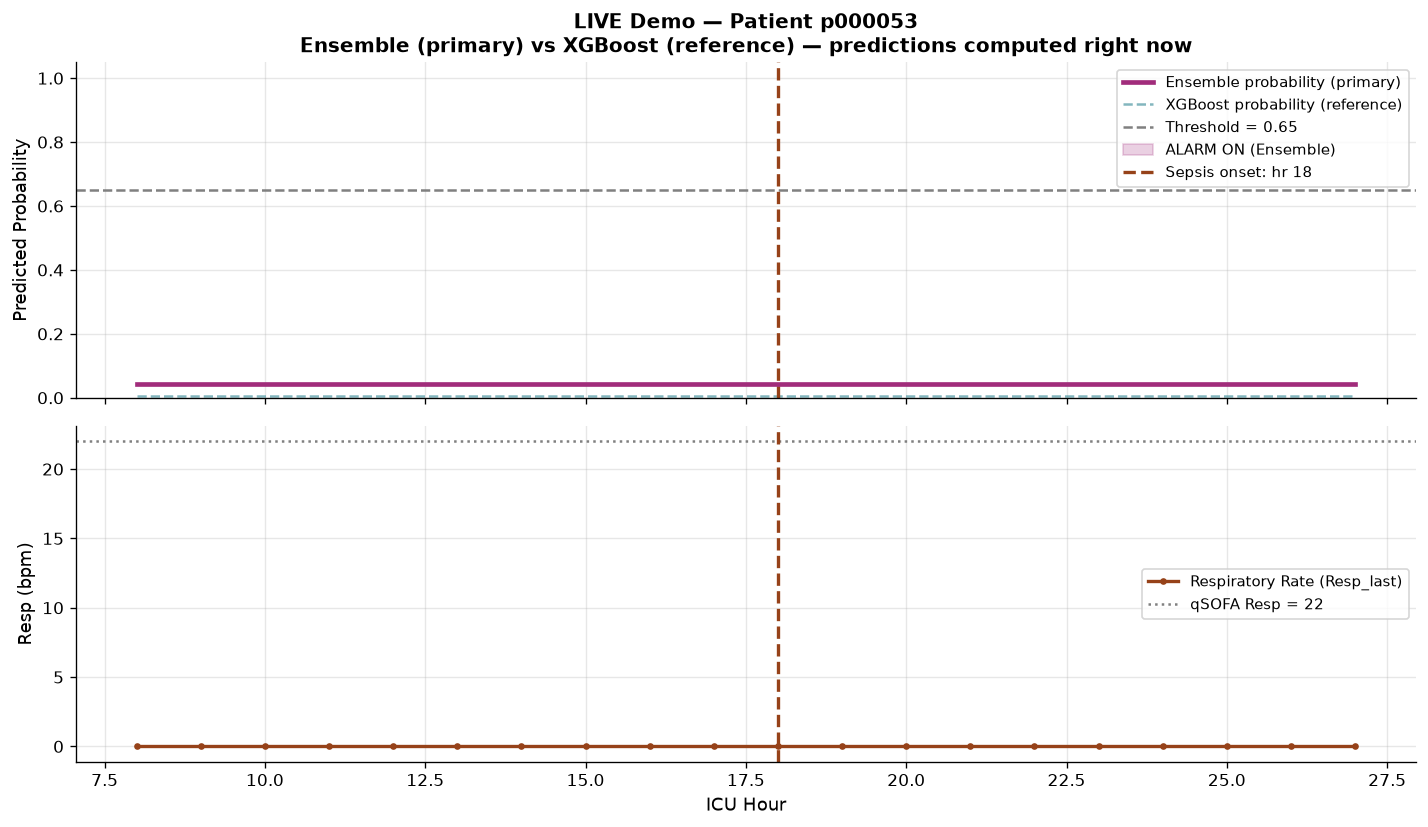

✅ Live demo complete — Ensemble is the primary model; XGBoost shown for comparison.
   Saved: artifacts/demo_trajectory.png


In [170]:
ew_pids  = demo_df[demo_df['eligibility_group'] == 'early_warning_eligible']['patient_id'].unique()
demo_pid = ew_pids[0] if len(ew_pids) > 0 else demo_pids[0]

pdf = demo_df[demo_df['patient_id'] == demo_pid].sort_values('ICULOS')
onset_hr = None
if pdf['label'].max() == 1:
    oi       = pdf['label'].values.argmax()
    onset_hr = float(pdf['ICULOS'].iloc[oi])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# ── Top panel: Ensemble (primary) + XGBoost (reference) ──────────────────────
ax1.plot(pdf['ICULOS'], pdf['live_ensemble_prob'], color='#a12c7b', lw=2.8,
         label='Ensemble probability (primary)', zorder=3)
ax1.plot(pdf['ICULOS'], pdf['live_xgb_prob'], color='#4f98a3', lw=1.5,
         ls='--', alpha=0.7, label='XGBoost probability (reference)', zorder=2)
ax1.axhline(THRESHOLD_LOADED, color='gray', ls='--', lw=1.5,
            label=f'Threshold = {THRESHOLD_LOADED}')
ax1.fill_between(
    pdf['ICULOS'], THRESHOLD_LOADED, pdf['live_ensemble_prob'],
    where=pdf['live_ensemble_prob'] >= THRESHOLD_LOADED,
    alpha=0.22, color='#a12c7b', label='ALARM ON (Ensemble)'
)
if onset_hr is not None:
    ax1.axvline(onset_hr, color='#964219', lw=2, ls='--',
                label=f'Sepsis onset: hr {onset_hr:.0f}')
ax1.set_ylabel('Predicted Probability')
ax1.set_ylim([0, 1.05])
ax1.set_title(
    f'LIVE Demo — Patient {demo_pid}\n'
    f'Ensemble (primary) vs XGBoost (reference) — predictions computed right now',
    fontweight='bold'
)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# ── Bottom panel: Respiratory rate ───────────────────────────────────────────
if 'Resp_last' in pdf.columns:
    ax2.plot(pdf['ICULOS'], pdf['Resp_last'], color='#964219', lw=2,
             marker='o', markersize=3, label='Respiratory Rate (Resp_last)')
    ax2.axhline(22, color='gray', ls=':', lw=1.5, label='qSOFA Resp = 22')
if onset_hr is not None:
    ax2.axvline(onset_hr, color='#964219', lw=2, ls='--')
ax2.set_ylabel('Resp (bpm)')
ax2.set_xlabel('ICU Hour')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/demo_trajectory.png', bbox_inches='tight')
plt.show()
print("✅ Live demo complete — Ensemble is the primary model; XGBoost shown for comparison.")
print(f"   Saved: artifacts/demo_trajectory.png")

---
## ✅ Final Pre-Presentation Checklist

| Done | Item |
|---|---|
| ✅ | `FORCE_RETRAIN` flag implemented — set `False` for demo (fast-load), `True` to retrain |
| ☐ | Fill in **course name, group number, team names, matriculation numbers** in Section 0 |
| ☐ | Download PhysioNet 2019 data and confirm `DATA_DIRS` paths in **Cell 2.3** |
| ✅ | Run **Section 5** once to train models and populate all `artifacts/` |
| ☐ | Run entire notebook top-to-bottom on a **clean kernel** with `FORCE_RETRAIN = False` |
| ☐ | Confirm notebook completes in < 60 seconds in fast-load mode |
| ☐ | Back up `artifacts/` folder (GitHub / USB / Drive) |
| ☐ | Every team member can explain: patient-level split, threshold selection, utility score |
| ☐ | Every team member can explain each of the 4 error analysis cases |
| ☐ | USB-C adapter + laptop charger packed |
